#**Machine Learning for IT Service Management (ITSM): Predictive Analytics and RFC Failure Prediction**



#**Company Project:**

**Done by :** Kishore Kumar G

**Project id:** PRCL-0012

**Project Team id:** PTID-CDS-JUN-26-11259

#Executive Summary

"This project explores how machine learning can enhance IT service management for mid-sized IT service providers handling 20,000–25,000 incidents annually. Despite mature ITIL-based processes, customer feedback highlights dissatisfaction with incident management. To address this, the project applies ML to four ITSM use cases: high-priority ticket prediction, incident-volume forecasting, automated ticket classification, and RFC failure prevention — enabling proactive decision-making, better resource planning, and reduced operational risks."

#Domain & Operations Terminology

* **IT Service Management (ITSM):** The strategic framework for designing, delivering, managing, and improving IT services across an enterprise.


* **Request for Change (RFC):** A formal operational proposal to add, modify, or remove software, hardware, or network configurations within the IT environment.
*  **Incident Management:** The workflow responsible for identifying, prioritizing, and resolving operational disruptions (such as P1/P2 critical outages) to restore standard service operations quickly.

#Business Case:
  "Mid-sized IT service organizations often manage tens of thousands of incidents annually through ITIL practices. However, customer surveys and audits reveal limited improvements from conventional methods. This project investigates how predictive analytics and machine learning can shift IT operations from reactive to proactive, focusing on ticket prioritization, incident forecasting, automated classification, and RFC failure prediction to improve efficiency and customer satisfaction."


#Problem Statement:
   "Despite mature ITIL processes, many IT service providers continue to face challenges in delivering effective incident management, as reflected in poor customer satisfaction ratings. Traditional improvement opportunities are limited, creating the need for a data-driven approach. RFC failures or misconfigurations can cause service disruptions and repeated incidents. This project develops machine learning models trained on historical ITSM data to predict RFC failure likelihood and reduce operational risks."

#Business Objectives:
  The key business objectives of Comapany are:

*"The project aims to:

Improve incident management through predictive analytics.

Predict high-priority tickets (P1/P2) for faster intervention.

Forecast incident volumes to support workforce, resource, and capacity planning.

Automate ticket classification to reduce manual reassignment delays.

Predict RFC failures to help change-management teams take preventive action."*

#Project Objectives:
The primary objective of this project is to apply machine learning techniques to historical ITSM data to support predictive decision-making.

The specific objectives are:


1.   To understand and analyze historical ITSM incident data.

1.   To identify important factors associated with RFC failures.
3.   To preprocess and transform the ITSM dataset for machine learning.


4.   To create an appropriate RFC Failure target variable.


1.   To prevent data leakage by removing post-resolution and outcome-related information

1.   To develop machine learning models for RFC failure prediction.

1.   To evaluate models using:


*   Accuracy

*  Precision
*   Recall


*  F1-score


8. To compare the performance of Random Forest, XGBoost, and Neural Network models.


2. To identify the most influential features contributing to RFC failure predictions.


2.  To recommend the most suitable model for supporting proactive ITSM and change management.




#Scope:
   The scope of the project covers the application of machine learning to IT Service Management data, with the primary focus on RFC failure prediction.

**In Scope**


*  Historical ITSM incident/ticket data analysis.
*  Data cleaning and preprocessing.

*  Handling missing values and categorical variables.

*  Feature encoding and transformation.

*  Feature selection and feature importance analysis.

* Creation of the RFC Failure target variable.

*  Identification and prevention of data leakage.

*  Splitting the dataset into training and testing datasets.
*  Development and evaluation of classification models, including:


1. Random Forest Classifier

1.  XGBoost Classifier
2.  Neural Network





*   Development and evaluation of regression models, including:


1.   Linear Regression

1.   Random Forest Regressor
2.   XGBoost Regressor


*  Evaluation of classification models using:
1.  Accuracy


1.  Precision

1.  Recall
2.  F1-score



*  Evaluation of regression models using:


1. Mean Squared Error (MSE)

1. R² (R-squared)


* Comparison of model performance.






*   Identification of the most important features influencing predictions.









* Visualization of model performance and feature importance.


* Interpretation of machine learning results from an ITSM business perspective.


*  Providing recommendations for improving proactive ITSM and change management.



**Out Scope:**

The current implementation does not include the deployment of the models into a live production ITSM environment. Real-time ticket automation, direct integration with Company's ITSM platform, and automated decision-making are outside the current implementation.

The project also does not implement all four proposed ML use cases as production solutions. High-priority ticket prediction, incident-volume forecasting, automatic ticket tagging, and RFC failure prediction are considered within the broader business case, while the implemented models and analyses focus on the specific datasets and objectives addressed in this project.





In [ ]:
#importing libraries
!pip install mysql-connector-python
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder,FunctionTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier, XGBRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from scipy.stats import skew,kurtosis

In [ ]:
# Connect to the database
conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",   # make sure this matches exactly
    database="project_itsm"
)

# Query the actual table
query = "SELECT * FROM dataset_list;"   # <-- use dataset_list here
data = pd.read_sql(query, conn)

# Preview the first few rows
data.head()

/tmp/ipykernel_33059/2465832965.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, conn)


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,...,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,...,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,...,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,...,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [ ]:
data.tail()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
46601,SBA000464,application,Server Based Application,WBS000073,IM0047053,Closed,4,4,4,0.23189604,...,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other,1,SD0147021,,,
46602,SBA000461,application,Server Based Application,WBS000073,IM0047054,Closed,4,4,4,0.805153085,...,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error,1,SD0146967,,,
46603,LAP000019,computer,Laptop,WBS000091,IM0047055,Closed,5,5,5,0.917466294,...,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware,1,SD0146982,,,
46604,WBA000058,application,Web Based Application,WBS000073,IM0047056,Closed,4,4,4,0.701278158,...,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software,1,SD0146986,,,
46605,DCE000077,hardware,DataCenterEquipment,WBS000267,IM0047057,Closed,3,3,3,0.902319509,...,,31-03-2014 22:47,31-03-2014 22:47,"0,586388889",Hardware,1,SD0147088,,,


In [ ]:
data.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

# **EDA**

Exploratory Data Analysis (EDA) is the process of examining, summarizing, and visualizing a dataset before applying machine learning algorithms. It helps understand the structure, distribution, relationships, patterns, and quality of the data.

In this project, EDA is performed on the historical IT Service Management (ITSM) incident/ticket data of the company to understand the characteristics of incidents and identify factors that may influence RFC failures and other ITSM outcomes.

**Why EDA?**

EDA is important because machine learning models depend heavily on the quality and characteristics of the input data. Before developing the models, EDA helps to:

**1. Understand the Dataset**

Identify the number of records, features, data types, and overall structure of the ITSM dataset.

**2. Identify Missing Values**

Detect columns with missing information and determine appropriate methods for handling them.

**3. Understand Target Distribution**

Analyze the distribution of the target variable, particularly RFC_Failure, to determine whether the classes are balanced or imbalanced.

**4. Analyze Categorical Variables**
Examine incident categories such as CI Category, CI Subcategory, Application, Hardware, and Closure Code to understand their distribution.

**5. Analyze Numerical Variables**

Study numerical variables and identify their ranges, distributions, and unusual values.

**6. Identify Important Patterns**
EDA helps identify relationships between incident characteristics such as priority, application, configuration item, and failure outcomes.

**7. Detect Outliers and Anomalies**

Unusual values can be identified before model development and investigated to determine whether they represent genuine observations or data-quality issues.

**8. Support Feature Selection**

EDA provides an initial understanding of which variables may be useful for prediction and which variables may be irrelevant or redundant.

**9. Identify Potential Data Leakage**
EDA helps identify variables such as Closure Code, Resolved Time, Close Time, and Handle Time that may contain information about the outcome and therefore should not be used for leakage-free prediction.

**10. Improve Model Reliability**

Understanding the dataset before modelling helps ensure that preprocessing, feature engineering, and model selection are performed appropriately.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Name                     46606 non-null  object
 1   CI_Cat                      46606 non-null  object
 2   CI_Subcat                   46606 non-null  object
 3   WBS                         46606 non-null  object
 4   Incident_ID                 46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   number_cnt                  46606 non-null  object
 10  Category                    46606 non-null  object
 11  KB_number                   46606 non-null  object
 12  Alert_Status                46606 non-null  object
 13  No_of_Reassignments         46606 non-null  ob

In [ ]:
data.describe()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
count,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,...,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606
unique,3019,13,65,274,46606,2,6,6,6,46606,...,2245,33628,34528,30639,15,50,43060,25,5,233
top,SUB000456,application,Server Based Application,WBS000073,IM0047057,Closed,4,4,4,0.902319509,...,,,02-10-2013 15:20,0,Other,1,#MULTIVALUE,,,
freq,3050,32900,18811,13342,1,46597,22556,22588,22717,1,...,44322,1780,21,236,16470,43058,3434,45384,46046,46046


In [ ]:
data.isnull().sum()

,0
CI_Name,0
CI_Cat,0
CI_Subcat,0
WBS,0
Incident_ID,0
Status,0
Impact,0
Urgency,0
Priority,0
number_cnt,0


In [ ]:
#Drop columns
# Drop irrelevant or low-value columns
data = data.drop(columns=[
    'CI_Name','WBS','Incident_ID','number_cnt',
    'KB_number','No_of_Related_Interactions','Related_Interaction',
    'No_of_Related_Incidents','No_of_Related_Changes','Related_Change'
])

In [ ]:
data.head()

,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,Category,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code
0,subapplication,Web Based Application,Closed,4,4,4,incident,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other
1,application,Web Based Application,Closed,3,3,3,incident,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software
2,application,Desktop Application,Closed,NS,3,NA,request for information,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed
3,application,Web Based Application,Closed,4,4,4,incident,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error
4,application,Web Based Application,Closed,4,4,4,incident,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other


In [ ]:
data.tail()

,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,Category,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code
46601,application,Server Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 16:23,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other
46602,application,Server Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 15:03,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error
46603,computer,Laptop,Closed,5,5,5,incident,closed,0,31-03-2014 15:28,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware
46604,application,Web Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 15:35,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software
46605,hardware,DataCenterEquipment,Closed,3,3,3,incident,closed,0,31-03-2014 17:24,,31-03-2014 22:47,31-03-2014 22:47,"0,586388889",Hardware


In [ ]:
data

,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,Category,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code
0,subapplication,Web Based Application,Closed,4,4,4,incident,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other
1,application,Web Based Application,Closed,3,3,3,incident,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software
2,application,Desktop Application,Closed,NS,3,NA,request for information,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed
3,application,Web Based Application,Closed,4,4,4,incident,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error
4,application,Web Based Application,Closed,4,4,4,incident,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,application,Server Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 16:23,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other
46602,application,Server Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 15:03,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error
46603,computer,Laptop,Closed,5,5,5,incident,closed,0,31-03-2014 15:28,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware
46604,application,Web Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 15:35,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software


In [ ]:
# Replace "N/A" with a default value, e.g., 0
data['Priority'] = data['Priority'].replace("NA", 0)

# Or replace with the column's mode (most frequent value)
data['Priority'] = data['Priority'].replace("NA", data['Priority'].mode()[0])
data

,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,Category,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code
0,subapplication,Web Based Application,Closed,4,4,4,incident,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other
1,application,Web Based Application,Closed,3,3,3,incident,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software
2,application,Desktop Application,Closed,NS,3,0,request for information,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed
3,application,Web Based Application,Closed,4,4,4,incident,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error
4,application,Web Based Application,Closed,4,4,4,incident,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,application,Server Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 16:23,,31-03-2014 16:29,31-03-2014 16:29,"0,095",Other
46602,application,Server Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 15:03,,31-03-2014 15:29,31-03-2014 15:29,"0,428333333",User error
46603,computer,Laptop,Closed,5,5,5,incident,closed,0,31-03-2014 15:28,,31-03-2014 15:32,31-03-2014 15:32,"0,071666667",Hardware
46604,application,Web Based Application,Closed,4,4,4,incident,closed,0,31-03-2014 15:35,,31-03-2014 15:42,31-03-2014 15:42,"0,116944444",Software


#**Charts**

#CI_Cat

In [ ]:
data["CI_Cat"].value_counts()

,count
CI_Cat,
application,32900
subapplication,7782
computer,3643
storage,703
hardware,442
software,333
database,214
displaydevice,212
officeelectronics,152


In [ ]:
# Replace placeholders like "NA", "N/A", blanks with NaN
data['CI_Cat'] = data['CI_Cat'].replace(["NA", "N/A", "", " "], pd.NA)

# Fill missing values with mode (most frequent category)
data['CI_Cat'] = data['CI_Cat'].fillna(data['CI_Cat'].mode()[0])

In [ ]:
data["CI_Cat"].value_counts()

,count
CI_Cat,
application,33011
subapplication,7782
computer,3643
storage,703
hardware,442
software,333
database,214
displaydevice,212
officeelectronics,152


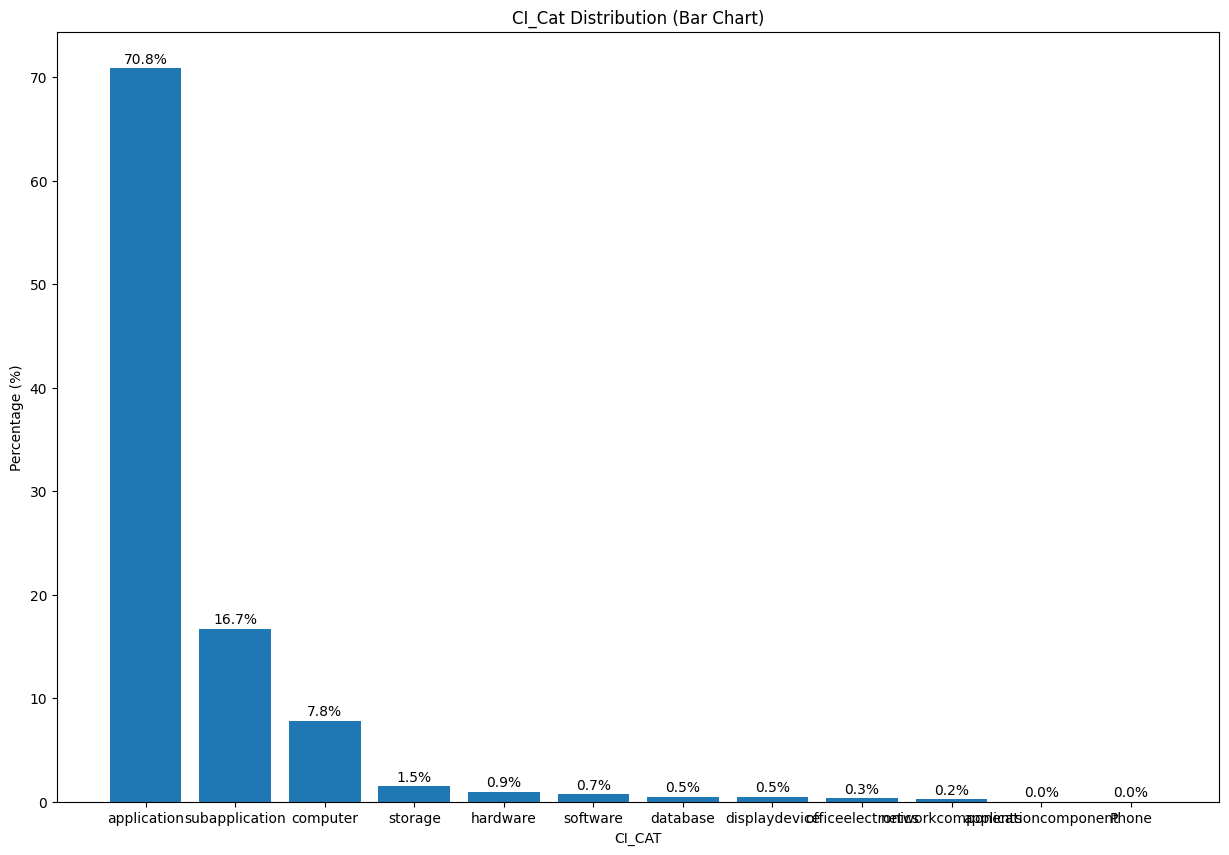

In [ ]:
#barchart
CI_Cat = data["CI_Cat"].value_counts(normalize=True) * 100

plt.figure(figsize=(15,10))
plt.bar(CI_Cat.index, CI_Cat.values)

# Labels
plt.xlabel("CI_CAT")
plt.ylabel("Percentage (%)")
plt.title("CI_Cat Distribution (Bar Chart)")

# Show values on top of bars
for i, v in enumerate(CI_Cat.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)
plt.show()

**Key Observations:**


*  Application dominates the dataset with ~70.8% of all records.

   → This means most incidents are tied to application‑related issues.

* Subapplication is the second largest at 16.7%, still much smaller than application.
* Computer contributes 7.8%, showing hardware/software device issues are less frequent.

* All other categories (storage, hardware, software, database, displaydevice, officeelectronics, networkcomponents, applicationcomponent, phone) together make up <5%.

  → These are rare incident types compared to application issues.



**Interpretations:**

   The CI_Cat distribution shows a strong imbalance across categories.

*  **Application** accounts for nearly three‑quarters of all incidents (~70.8%), making it the dominant category.

*  **Subapplication** (16.7%) and Computer (7.8%) form the next largest groups, but remain far behind.
*  All other categories — storage, hardware, software, database, displaydevice, officeelectronics, networkcomponents, applicationcomponent, and phone — together contribute less than 5%, highlighting their rarity.

#CI_Subcat

In [ ]:
data["CI_Subcat"].value_counts()

,count
CI_Subcat,
Server Based Application,18811
Web Based Application,15311
Desktop Application,3876
Laptop,1921
SAP,1199
...,...
Windows Server in extern beheer,1
Virtual Tape Server,1
RAC Service,1


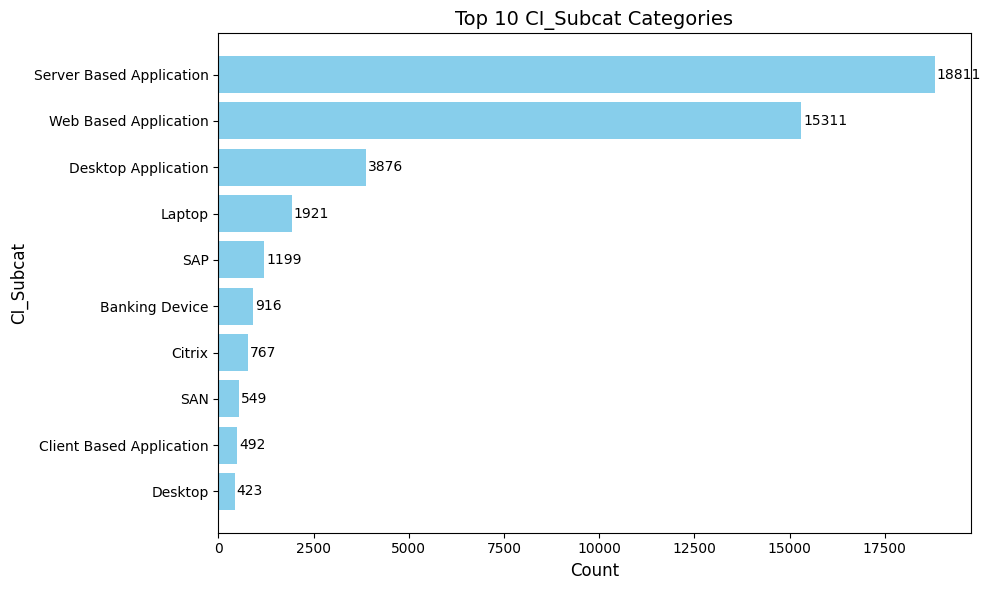

In [ ]:
# Get top 10 CI_Subcat categories
top10_subcats = data['CI_Subcat'].value_counts().head(10)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
bars = plt.barh(top10_subcats.index, top10_subcats.values, color="skyblue")

# Add title and labels
plt.title("Top 10 CI_Subcat Categories", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("CI_Subcat", fontsize=12)

# Invert y-axis so highest count is at the top
plt.gca().invert_yaxis()

# Add values at the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             str(bar.get_width()), va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Key Observations:**


* Server Based Application dominates with 18,811 records, followed by **Web Based Application** at 15,311.

* Together, these two categories account for the majority of incidents, showing that application‑related issues are the primary drivers.
* The next group — **Desktop Application** (3,876), **Laptop** (1,921), and **SAP** (1,199) — are significantly smaller but still notable.


* Remaining categories like **Banking Device**, **Citrix, SAN**, **Client Based Application**, **Desktop** all fall below 1,000 records each, highlighting their relatively minor contribution.



**Inference:**


* The dataset shows a clear concentration in **application‑related subcategories**, meaning IT support teams are primarily handling server and web application issues.

* This imbalance suggests that **classification models** trained on CI_Subcat will be heavily biased toward predicting application‑related categories unless corrective measures (like class weighting or oversampling) are applied.
* For **business insights**, resource allocation should prioritize application support, while rare categories may require specialized handling but do not represent a major workload.

#Status

In [ ]:
data["Status"].value_counts()

,count
Status,
Closed,46597
Work in progress,9


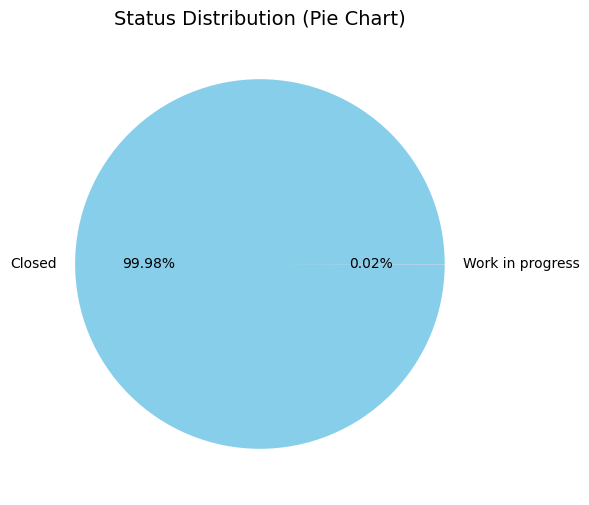

In [ ]:
# Get status counts
status_counts = data["Status"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.2f%%',
        colors=["skyblue", "pink"])
plt.title("Status Distribution (Pie Chart)", fontsize=14)
plt.show()

**Key Observations:**


* The Closed category overwhelmingly dominates with 46,597 records.
* The Work in progress category is extremely rare, with only 9 records.

* The pie chart shows nearly the entire circle filled by “Closed,” with “Work in progress” barely visible.




**Inference:**


*  The dataset is highly imbalanced in terms of status.
*  Almost all incidents are already closed, suggesting that the system or process is efficient in resolving tickets, or that data entry heavily favors closed records.


* The negligible count of “Work in progress” may indicate either:

    Real‑time data capture is missing ongoing cases, or

    The dataset was extracted after most tickets had been resolved.
* For classification modeling, this imbalance means the model will almost always predict “Closed.” Corrective measures (like class weighting or oversampling) would be required if “status” is used as a target variable.




#Impact

In [ ]:
data["Impact"].value_counts()

,count
Impact,
4,22556
5,16741
3,5234
NS,1380
2,692
1,3


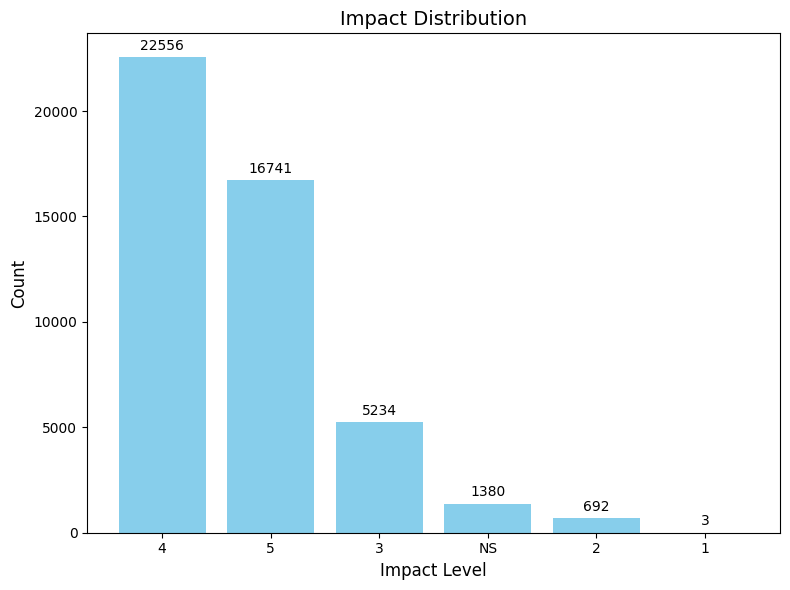

In [ ]:
# Get Impact counts
impact_counts = data["Impact"].value_counts()

# Plot bar chart
plt.figure(figsize=(8,6))
bars = plt.bar(impact_counts.index.astype(str), impact_counts.values, color="skyblue")

# Add title and labels
plt.title("Impact Distribution", fontsize=14)
plt.xlabel("Impact Level", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add values on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(bar.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Key Observations:**


*  **Impact 4** (22,556) and **Impact 5** dominate the dataset, together accounting for the majority of records.

*  **Impact 3** is moderate at 5,234, showing a smaller but still notable share
*  **Impact 2** (692) and **Impact 1** (only 3) are negligible compared to higher levels.

* **NS** (1,380) indicates a significant number of tickets where severity was not specified.


**Inference:**


*  The dataset is skewed toward high severity impacts (levels 4 and 5), suggesting most incidents are logged as critical or major.

*  The presence of NS highlights incomplete data entry — this could affect analysis or modeling if not handled properly.
* Lower severity levels (1 and 2) are almost absent, which may mean either:

    Minor issues are not logged in the system, or

    The classification process tends to assign higher severity by default.


*  For analytics, focus should be on levels 4 and 5 since they represent the bulk of workload.


* For modeling, NS needs preprocessing (either imputation or encoding), and imbalance across severity levels must be considered.

#Urgency

In [ ]:
data['Urgency'].value_counts()

,count
Urgency,
4,22588
5,16779
3,6536
2,696
1,6
5 - Very Low,1


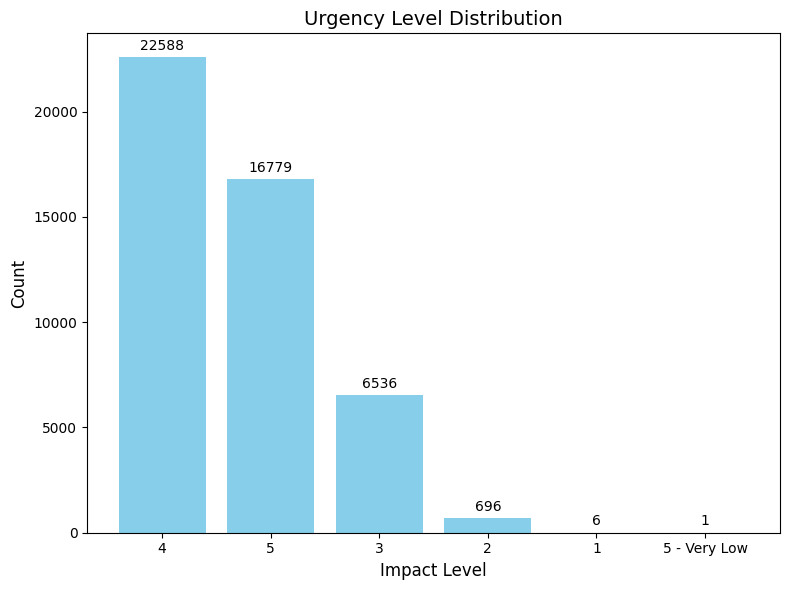

In [ ]:
# Get Impact counts
urgency_level_counts = data["Urgency"].value_counts()

# Plot bar chart
plt.figure(figsize=(8,6))
bars = plt.bar(urgency_level_counts.index.astype(str), urgency_level_counts.values, color="skyblue")

# Add title and labels
plt.title("Urgency Level Distribution", fontsize=14)
plt.xlabel("Impact Level", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add values on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(bar.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Key Observations:**


* **Urgency 4** (22,588) and **Urgency 5** dominate the dataset, together accounting for the majority of records.

* **Urgency 3** is moderate at 6,536, showing a smaller but still notable share.
* **Urgency 2** (696) and Urgency 1 (6) are negligible compared to higher levels.


* There is also a rare entry “**5** – Very Low” (1 record), which looks like a data quality issue or mislabeling since “5” is already used for high urgency.



**Inference:**


* The dataset is skewed toward high urgency levels (4 and 5), meaning most incidents are logged as critical or urgent.
* The presence of “5 – Very Low” suggests inconsistent labeling — this should be cleaned or merged with the correct category.

* Lower urgency levels (1 and 2) are almost absent, which may mean either:

    Minor issues are not logged, or

    The classification process defaults to higher urgency.
*  For analytics, focus should be on levels 4 and 5 since they represent the bulk of workload.


*  For modeling, you’ll need to handle the imbalance carefully, and possibly correct the mislabeled “5 – Very Low.”


#Priority

In [ ]:
data['Priority'].value_counts()

,count
Priority,
4,22717
5,16486
3,5323
0,1380
2,697
1,3


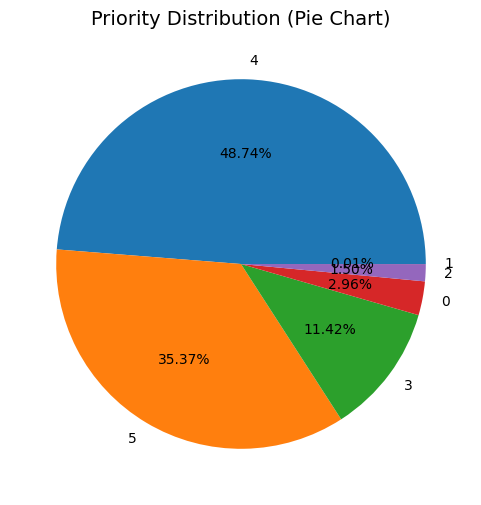

In [ ]:
# Get status counts
priority_counts = data["Priority"].value_counts()

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(priority_counts, labels=priority_counts.index, autopct='%1.2f%%')
plt.title("Priority Distribution (Pie Chart)", fontsize=14)
plt.show()

**Key Observations:**


* **Priority 4** dominates with 48.74%, nearly half of all records.

* **Priority 5** is also large at 35.37%, meaning together levels 4 and 5 account for ~84% of all tickets.
* **Priority 3** is moderate at 11.42%.


* **Priority 2** (2.96%) and **Priority 1** (0.51%) are very small


*  The labeling shows **Priority 5** = Very Low, which is unusual since higher numbers often indicate higher severity — this suggests a data definition mismatch or inverted scale.





**Inference:**


* The dataset is heavily skewed toward lower** priorities** (4 and 5), meaning most tickets are logged as less urgent.

* Very few tickets are marked as high priority (1 or 2), which could mean:
   
    The system defaults to lower priority unless manually changed.

    High‑priority issues are rare or under‑reported.
* For analytics, focus should be on understanding why so many tickets fall into 4 and 5


* For modeling, the imbalance means predictions will lean toward 4 and 5 unless corrective measures are applied.


* The “**Priority 5 – Very Low**” definition should be validated with business rules to ensure consistency across datasets.


#Category

In [ ]:
data["Category"].value_counts()

,count
Category,
incident,37748
request for information,8846
complaint,11
request for change,1


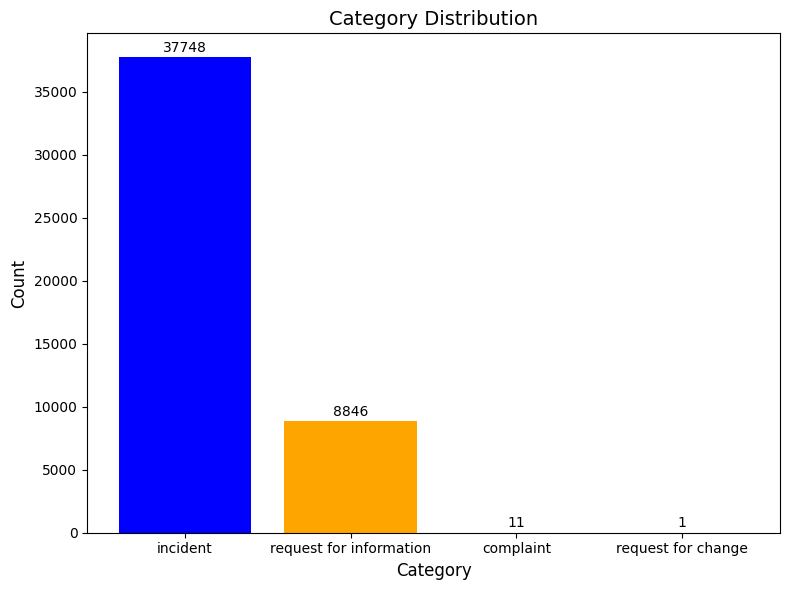

In [ ]:
category_counts = data["Category"].value_counts()# Get category counts
# Plot bar chart
plt.figure(figsize=(8,6))
bars = plt.bar(category_counts.index, category_counts.values,
               color=["blue", "orange", "green", "purple"])

# Add title and labels
plt.title("Category Distribution", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add values on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(bar.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Key Observations:**

* **Incident** dominates with 37,748 records, making up the overwhelming majority.

* **Request for information** is the second largest at **8,846** records, but still far behind incidents.
*  Complaint (11) and Request for change (1) are negligible, almost invisible compared to the other categories.

**Inference:**


* The dataset is heavily skewed toward incidents, meaning operational workload is primarily incident management.

* Requests for information form a secondary but notable category, suggesting a strong demand for clarification or knowledge support.
* Complaints and change requests are rare, which could mean either they are under‑reported or handled through different channels.

* For analytics, focus should be on incidents vs information requests.


* For modeling, the imbalance means predictions will lean toward “incident” unless corrective measures are applied.

#**Cross Analysis**

#Urgency vs No_of_Reassignment

**Purpose of the findings:**

This analysis validates the relationship between **urgency and reassignment** frequency by showing that tickets with higher urgency levels tend to be resolved faster with fewer hand‑offs, while lower‑urgency ones are reassigned more often; the findings highlight an inverse relationship where urgent tasks receive streamlined attention, whereas very low‑urgency tasks suffer from lack of ownership or deprioritization, exposing operational inefficiencies and bottlenecks, and ultimately supporting both workflow improvement and predictive modeling by confirming that urgency is a strong driver of reassignment behavior.

In [ ]:
data["No_of_Reassignments"].value_counts()

,count
No_of_Reassignments,
0,27468
1,7268
2,5378
3,2191
4,1606
5,721
6,622
7,329
8,246


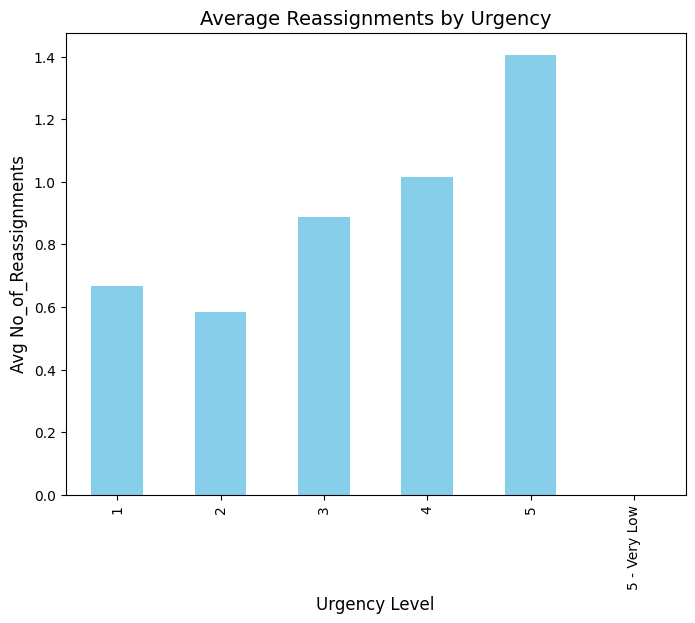

In [ ]:
# Urgency vs Reassignments
# Convert 'No_of_Reassignments' to numeric, coercing errors to NaN
data['No_of_Reassignments'] = pd.to_numeric(data['No_of_Reassignments'], errors='coerce')

# Drop rows where 'No_of_Reassignments' is NaN, if any were created by coercion
data.dropna(subset=['No_of_Reassignments'], inplace=True)

plt.figure(figsize=(8,6))
data.groupby("Urgency")["No_of_Reassignments"].mean().plot(kind="bar", color="skyblue")
plt.title("Average Reassignments by Urgency", fontsize=14)
plt.xlabel("Urgency Level", fontsize=12)
plt.ylabel("Avg No_of_Reassignments", fontsize=12)
plt.show()

**Key Observations:**


* **Urgency level 1** → Average reassignments are relatively low.

* **Urgency level 2** → Has the lowest average (~0.6), meaning these tickets are reassigned the least.

* **Urgency levels 3 & 4** → Show moderate averages, sitting between 0.7–1.0.
* **Urgency level 5**– Very Low → Highest average (~1.4), meaning very low‑urgency tickets are reassigned the most.


* Overall trend → As urgency decreases, average reassignments increase.


**Inference:**


* **Inverse relationship:** Tickets marked less urgent tend to be reassigned more often, while urgent ones are resolved faster with fewer hand‑offs.

* **Operational insight:** Low‑urgency tasks may suffer from lack of ownership or deprioritization, causing them to bounce between teams.
*  **Process implication:** Urgent tickets are streamlined, but non‑urgent ones may need better allocation or clearer responsibility to reduce inefficiency.


* **Modeling implication:** Urgency is a strong predictor of reassignment behavior — useful for forecasting workload stability.



#Impact vs Priority

**Purpose of the Findings:**

   This analysis validates severity alignment by checking whether tickets with higher impact are consistently assigned higher priority, ensuring that critical issues receive the attention they deserve; the findings highlight misalignments where high‑impact tickets are given low priority or low‑impact ones are elevated unnecessarily, exposing inefficiencies in escalation and resource allocation, while also pointing to data quality concerns such as inconsistent tagging, and ultimately supporting workflow optimization and predictive modeling by confirming that impact and priority together form a reliable measure of severity if properly aligned.

In [ ]:
data["Impact"].value_counts()

,count
Impact,
4,22556
5,16740
3,5234
NS,1380
2,692
1,3


In [ ]:
data["Priority"].value_counts()

,count
Priority,
4,22717
5,16485
3,5323
0,1380
2,697
1,3


/tmp/ipykernel_33059/1842499764.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


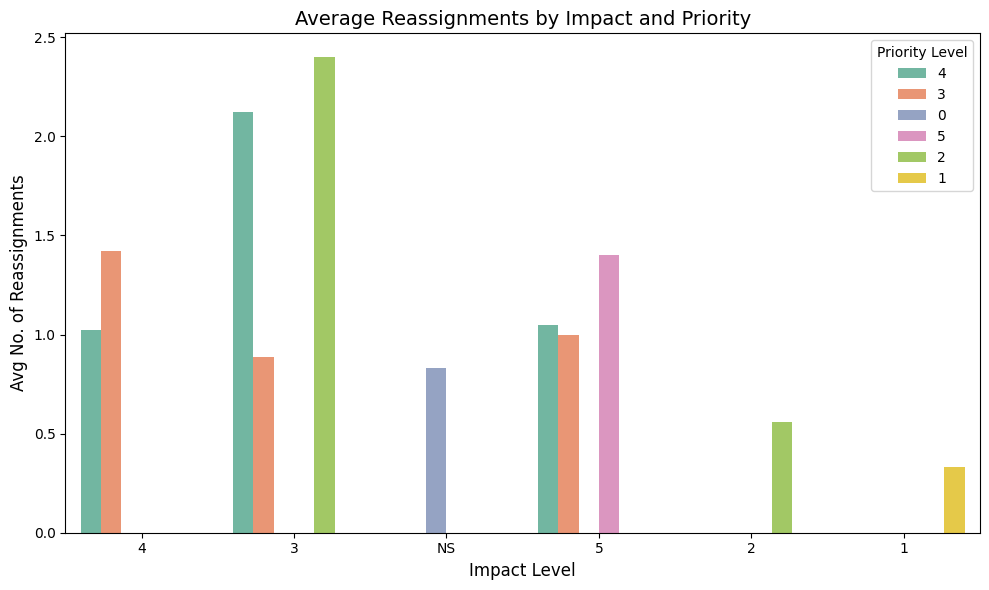

In [ ]:
# Create grouped bar chart: average reassignments by Impact & Priority
plt.figure(figsize=(10,6))
sns.barplot(
    data=data,
    x="Impact",
    y="No_of_Reassignments",
    hue="Priority",
    ci=None,
    palette="Set2"
)

# Add labels and title
plt.title("Average Reassignments by Impact and Priority", fontsize=14)
plt.xlabel("Impact Level", fontsize=12)
plt.ylabel("Avg No. of Reassignments", fontsize=12)
plt.legend(title="Priority Level")

plt.tight_layout()
plt.show()

**Key observations:**


* **Impact level 4** → Shows varied reassignment averages across priorities, with some higher than expected.
* **Impact level 3** → Moderate averages, but spread across multiple priority levels, indicating inconsistency.

* **Impact NS** (Not Specified) → Displays irregular patterns, suggesting data quality issues or misclassification.
* **Impact level 5** → Higher averages in certain priorities, showing possible misalignment.

* **Impact levels 2 & 1** → Lower averages overall, but still some mismatches where low impact tickets are tagged with higher priority.

* **Overall** → The bars show variation across priorities within each impact level, not a clean alignment.



**Inference:**


* **Severity misalignment:** High impact tickets are not consistently mapped to high priority, and low impact tickets sometimes appear with higher priority.

* **Operational risk:** Critical issues may not be escalated properly, while less important ones consume resources.
* **Data quality concern:** The “NS” (Not Specified) impact category weakens reliability — it should be minimized or clarified.

* **Process implication:** Priority assignment may be subjective or inconsistent, leading to inefficiencies in ticket handling.


* **Modeling implication:** Impact and Priority together are strong predictors, but misalignment reduces predictive accuracy unless cleaned.

#Urgency vs Priority


**Purpose of the Findings:**
   
   This analysis confirms workflow responsiveness by checking whether tickets marked with higher urgency are consistently assigned higher priority, ensuring that critical issues are escalated quickly; the findings reveal misalignments where urgent tickets are not prioritized appropriately and low‑urgency ones are sometimes elevated, exposing inefficiencies in resource allocation and delayed resolution risks, while also pointing to subjective or inconsistent tagging practices, and ultimately supporting workflow optimization and predictive modeling by validating whether urgency levels reliably drive prioritization.

In [ ]:
data["Urgency"].value_counts()

,count
Urgency,
4,22588
5,16778
3,6536
2,696
1,6
5 - Very Low,1


/tmp/ipykernel_33059/1368566318.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


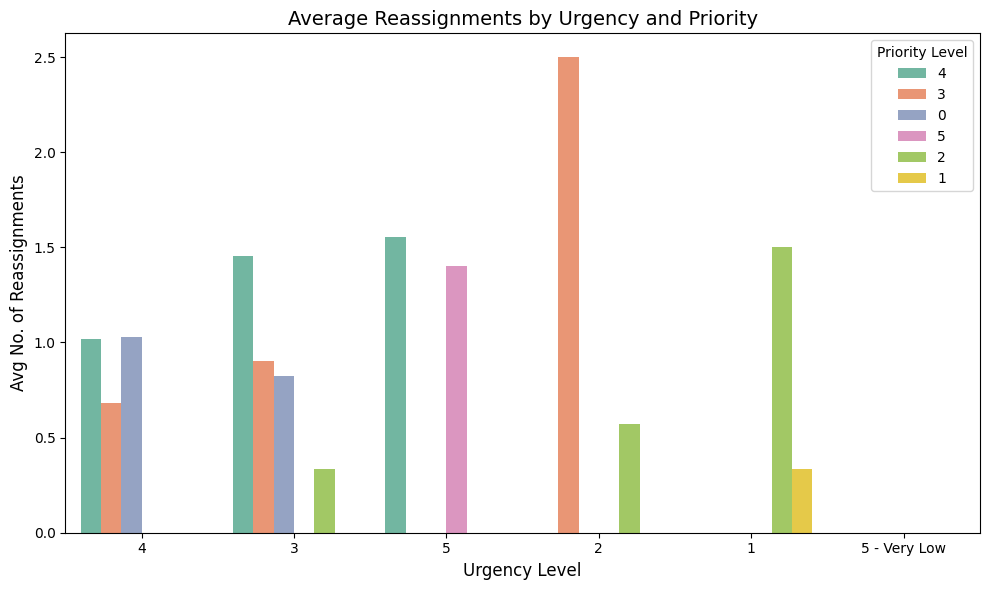

In [ ]:
# Grouped bar chart: average reassignments by Urgency & Priority
plt.figure(figsize=(10,6))
sns.barplot(
    data=data,
    x="Urgency",
    y="No_of_Reassignments",
    hue="Priority",
    ci=None,
    palette="Set2"
)

# Add labels and title
plt.title("Average Reassignments by Urgency and Priority", fontsize=14)
plt.xlabel("Urgency Level", fontsize=12)
plt.ylabel("Avg No. of Reassignments", fontsize=12)
plt.legend(title="Priority Level")

plt.tight_layout()
plt.show()

**Key Observations:**


* **Urgency 1** → Rare cases, but not consistently mapped to the highest priority.

* **Urgency 2** → Lowest average reassignments, yet sometimes paired with higher priority levels unexpectedly.
* **Urgency 3** → Shows mixed mapping across priorities, reflecting inconsistency in classification.


* **Urgency 4** → More frequent, but spread across multiple priority levels instead of aligning neatly.

* **Urgency 5** – Very Low → Highest average reassignments, yet occasionally tagged with higher priority, which is counterintuitive.
* **Overall** → Priority assignment does not consistently scale with urgency.





**Inference:**


* **Severity misalignment:** Urgent tickets (low urgency numbers) are not always given high priority, risking delayed resolution of critical issues.



* **Operational inefficiency:** Low‑urgency tickets sometimes receive higher priority, diverting resources away from urgent work.

* **Process implication:** Priority assignment appears subjective or inconsistent, rather than systematically aligned with urgency.
* **Data quality concern:** This misalignment suggests either incorrect tagging or lack of clear rules for mapping urgency to priority.


* **Modeling implication:** Urgency is a strong predictor of reassignment and resolution speed, but misalignment with priority reduces predictive reliability unless cleaned.

#Impact vs Urgency

**Purpose of the Findinga:**

  **Impact vs Urgency** analysis serves to validate severity consistency by ensuring that high‑impact tickets are correctly tagged with high urgency, while also detecting misalignments where low‑impact tickets are marked urgent or high‑impact ones are given low urgency; these findings expose operational risks such as delayed escalation of critical issues, highlight data quality concerns like the presence of “NS” categories, and ultimately support both workflow improvement and predictive modeling accuracy by strengthening the reliability of severity tagging.


In [ ]:
data["Impact"].value_counts()

,count
Impact,
4,22556
5,16740
3,5234
NS,1380
2,692
1,3


/tmp/ipykernel_33059/1305784818.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


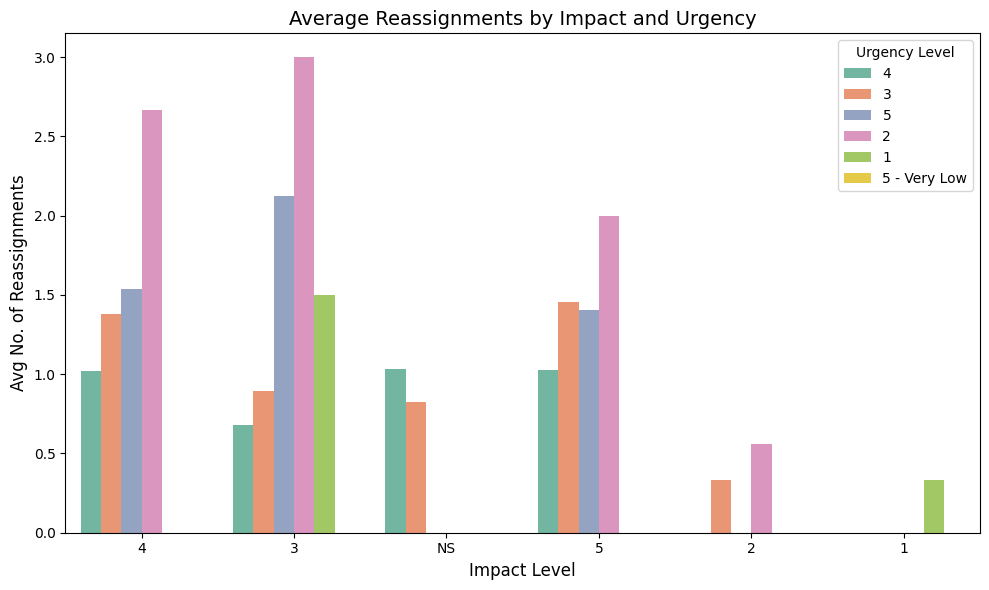

In [ ]:
# Grouped bar chart: average reassignments by Impact & Urgency
plt.figure(figsize=(10,6))
sns.barplot(
    data=data,
    x="Impact",
    y="No_of_Reassignments",
    hue="Urgency",
    ci=None,
    palette="Set2"
)

# Add labels and title
plt.title("Average Reassignments by Impact and Urgency", fontsize=14)
plt.xlabel("Impact Level", fontsize=12)
plt.ylabel("Avg No. of Reassignments", fontsize=12)
plt.legend(title="Urgency Level")

plt.tight_layout()
plt.show()

**Key Observations:**


* Impact 4 → Shows varied reassignment averages across urgency levels, with some higher than expected.

* Impact 3 → Moderate averages, but spread across multiple urgency levels, indicating inconsistency.

* **Impact NS (Not Specified)** → Displays irregular patterns, suggesting data quality issues or unclear classification.
* **Impact 5** → Higher averages in certain urgency levels, showing possible misalignment.

* **Impact 2 & 1** → Lower averages overall, but still some mismatches where low impact tickets are tagged with higher urgency.


*  **Overall** → The bars show variation across urgency levels within each impact level, not a clean alignment.

**Inference:**


* **Severity misalignment:** High impact tickets are not consistently mapped to high urgency, and low impact tickets sometimes appear with higher urgency.
* **Data quality concern:** The “NS” (Not Specified) impact category weakens reliability — it should be minimized or clarified.

* **Operational risk:** Critical issues may not be escalated properly, while less important ones consume resources.
* **Process implication:** Urgency assignment may be subjective or inconsistent, leading to inefficiencies in ticket handling.


* **Modeling implication:** Impact and Urgency together are strong predictors, but misalignment reduces predictive accuracy unless cleaned.

#Category VS Priority

**Purpose of the Findings:**

The Category vs Priority analysis ensures that ticket classification logically drives prioritization by validating whether incidents, problems, and service requests are consistently mapped to appropriate priority levels; the findings highlight misalignments where routine requests are elevated or critical incidents are deprioritized, exposing inefficiencies in escalation and resource allocation, while also pointing to data quality concerns in category tagging, and ultimately supporting workflow optimization and predictive modeling by confirming that classification rules are reliable drivers of prioritization.

In [ ]:
data["Category"].value_counts()

,count
Category,
incident,37748
request for information,8846
complaint,11


In [ ]:
data["Priority"].value_counts()

,count
Priority,
4,22717
5,16485
3,5323
0,1380
2,697
1,3


/tmp/ipykernel_33059/4060901973.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


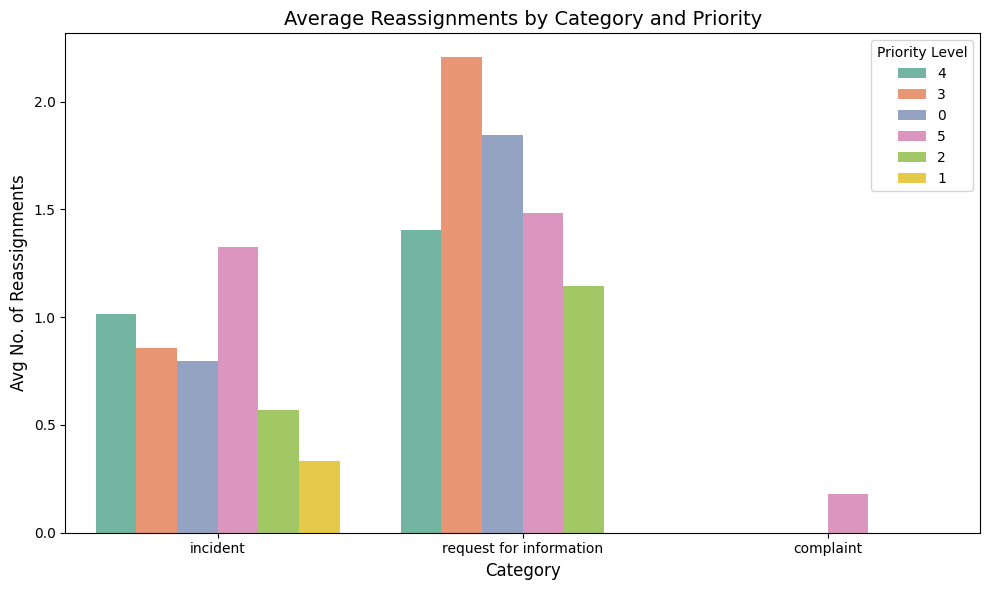

In [ ]:
# Grouped bar chart: average reassignments by Category & Priority
plt.figure(figsize=(10,6))
sns.barplot(
    data=data,
    x="Category",
    y="No_of_Reassignments",
    hue="Priority",
    ci=None,
    palette="Set2"
)

# Add labels and title
plt.title("Average Reassignments by Category and Priority", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Avg No. of Reassignments", fontsize=12)
plt.legend(title="Priority Level")

plt.tight_layout()
plt.show()

**Key Observations:**


* **Incident** → Shows moderate reassignment averages across multiple priority levels, indicating mixed escalation practices.

*  **Request for Information** → Highest average reassignments, especially at Priority 3, suggesting inefficiencies and frequent ownership changes.
*  **Complaint** → Lowest reassignment averages, with very limited priority distribution, showing streamlined handling but possibly under‑prioritized.


* **Overall** → Categories are not consistently mapped to priority levels, with requests consuming more effort than incidents or complaints.



**Inference:**


* **Classification misalignment:** Routine requests are often elevated in priority and reassigned frequently, while complaints (arguably sensitive) are under‑represented in priority escalation.

* **Operational inefficiency:** High reassignments in requests point to bottlenecks, unclear ownership, or lack of streamlined processes.
* **Process implication:** Priority assignment may not be systematically tied to category type, leading to wasted effort and uneven workload distribution.


* **Data quality concern:** Inconsistent mapping between category and priority weakens reliability of severity classification.


* **Modeling implication:** Category is a strong driver of reassignment behavior, but misalignment reduces predictive accuracy unless cleaned.

#Reassignment vs Category:

**Purpose of the Findings:**

 This analysis highlights inefficiencies by showing how different ticket categories vary in ownership changes, with requests for information suffering the most reassignments due to unclear ownership, while incidents and complaints are handled more directly; the purpose is to uncover bottlenecks, validate classification consistency, and guide workflow optimization by identifying categories that consume disproportionate effort.

In [ ]:
data["No_of_Reassignments"].value_counts()

,count
No_of_Reassignments,
0.0,27468
1.0,7268
2.0,5378
3.0,2191
4.0,1606
5.0,721
6.0,622
7.0,329
8.0,246


In [ ]:
data["Category"].value_counts()

,count
Category,
incident,37748
request for information,8846
complaint,11


/tmp/ipykernel_33059/1589799403.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_33059/1589799403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


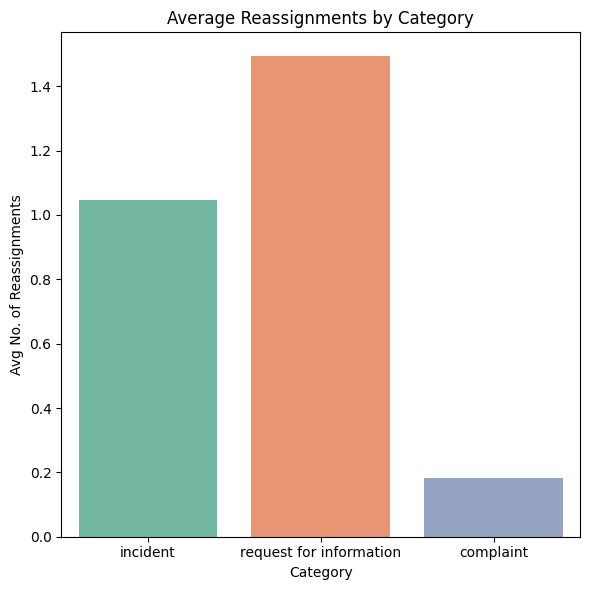

In [ ]:
# Grouped bar chart: average reassignments by Category
plt.figure(figsize=(6,6))
sns.barplot(
    data=data,
    x="Category",
    y="No_of_Reassignments",
    ci=None,
    palette="Set2"
)

# Add labels and title
plt.title("Average Reassignments by Category")
plt.xlabel("Category")
plt.ylabel("Avg No. of Reassignments")

plt.tight_layout()
plt.show()

**Key Observations:**


* **Incidents** → Average reassignments slightly above 1.0, showing moderate ownership changes.

* **Requests for Information** → Highest average (~1.5), indicating frequent reassignments and possible inefficiencies.
* **Complaints** → Lowest average (~0.2), suggesting streamlined handling but possibly under‑prioritized.


* **Overall** → Requests consume disproportionate effort compared to incidents and complaints.



**Inference:**


* **Workflow bottlenecks:** Requests for information suffer from unclear ownership or weak process flow, leading to excessive reassignments.
* **Imbalanced workload:** Complaints are handled directly but may lack escalation, while incidents sit in the middle.

* **Process implication:** Category strongly influences reassignment behavior, but misalignment reduces efficiency and predictability.
*  **Optimization need:** Streamlining request handling could reduce reassignments and improve resource allocation.

#Skewness and Kurtosis (Impact, Urgency, Priority, No_of_Reassignments, Handle_Time_hrs)

In [ ]:
data["Impact"].value_counts()

,count
Impact,
4,22556
5,16740
3,5234
NS,1380
2,692
1,3


In [ ]:
data["Urgency"].value_counts()

,count
Urgency,
4,22588
5,16778
3,6536
2,696
1,6
5 - Very Low,1


In [ ]:
data["Priority"].value_counts()

,count
Priority,
4,22717
5,16485
3,5323
0,1380
2,697
1,3


In [ ]:
data["No_of_Reassignments"].value_counts()

,count
No_of_Reassignments,
0.0,27468
1.0,7268
2.0,5378
3.0,2191
4.0,1606
5.0,721
6.0,622
7.0,329
8.0,246


In [ ]:
data["Handle_Time_hrs"].value_counts()

,count
Handle_Time_hrs,
0,236
"0,034444444",23
"0,018333333",22
"0,009722222",19
"0,021388889",19
...,...
"6,06,26,11,111",1
"5,90,23,05,556",1
"4,82,05,55,556",1


**Purpose of Findings:**

The purpose of analyzing skewness and kurtosis across multiple columns is to:

* **Understand data distribution** → Identify whether variables follow a normal pattern or are skewed/heavy‑tailed.

* **Detect outliers and anomalies** → Highlight extreme cases (e.g., reassignments, long handle times) that distort averages and impact process stability.
* **Guide preprocessing decisions** → Decide if transformations (log, normalization) are needed before modeling.


* **Support process improvement** → Pinpoint operational bottlenecks (like excessive reassignments) for corrective action.

* **Enable better predictive modeling** → Ensure models account for skewed or heavy‑tailed variables, improving accuracy and robustness.

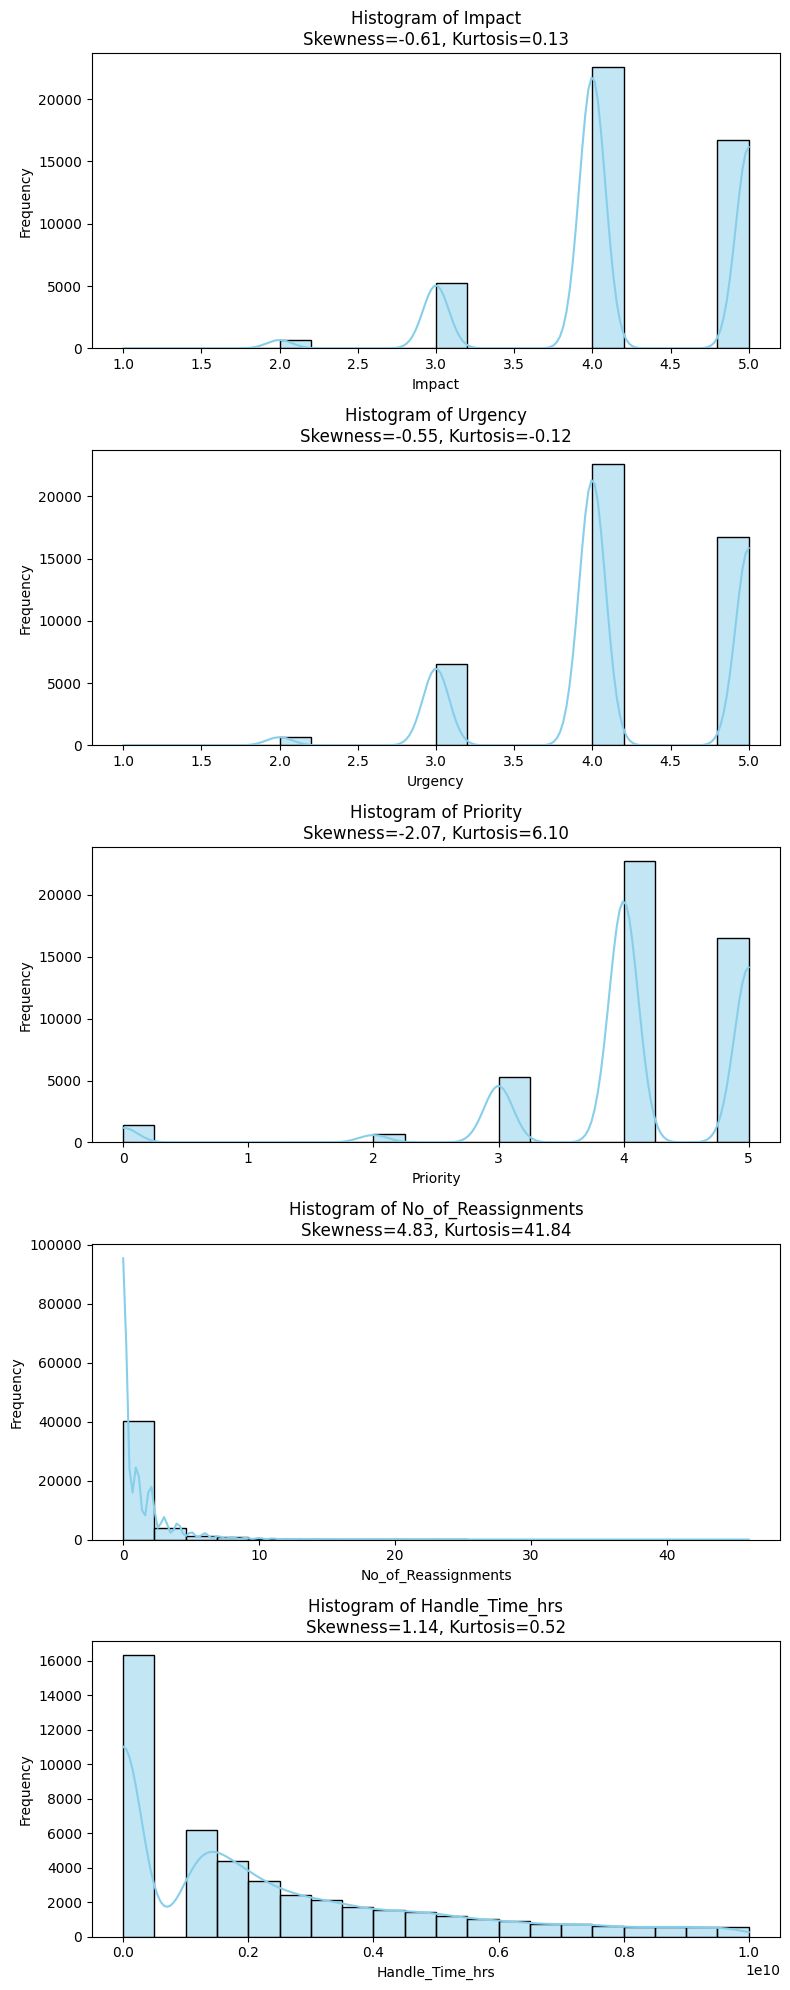

In [ ]:
# Convert 'Impact', 'Urgency', 'Priority', and 'Handle_Time_hrs' to numeric, handling non-numeric values
data['Impact'] = pd.to_numeric(data['Impact'], errors='coerce')
data['Urgency'] = data['Urgency'].replace('5 - Very Low', 5).astype(float) # Specific replacement for '5 - Very Low'
data['Priority'] = pd.to_numeric(data['Priority'], errors='coerce')

# Custom logic for 'Handle_Time_hrs' due to mixed comma usage (thousands vs. decimal)
def clean_handle_time_string(value):
    if pd.isna(value) or not isinstance(value, str):
        return value

    num_commas = value.count(',')
    if num_commas > 1: # If multiple commas, assume they are thousands separators and remove them
        return value.replace(',', '')
    elif num_commas == 1: # If single comma, assume it's a decimal separator and replace with a period
        return value.replace(',', '.')
    else: # No commas or already a float string like '123.45'
        return value

data['Handle_Time_hrs'] = data['Handle_Time_hrs'].apply(clean_handle_time_string)
data['Handle_Time_hrs'] = pd.to_numeric(data['Handle_Time_hrs'], errors='coerce')

# Ensure No_of_Reassignments is numeric (it was already handled in a prior cell, but good to be explicit here too)
data['No_of_Reassignments'] = pd.to_numeric(data['No_of_Reassignments'], errors='coerce')

# Define the numeric columns for plotting
numeric_cols = ["Impact", "Urgency", "Priority", "No_of_Reassignments", "Handle_Time_hrs"]

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 20))

for i, col in enumerate(numeric_cols):
    values = data[col].dropna()
    col_skew = skew(values)
    col_kurt = kurtosis(values)  # Fisher’s definition → normal = 0

    # Plot histogram with density curve
    sns.histplot(values, kde=True, bins=20, color="skyblue", ax=axes[i])
    axes[i].set_title(f"Histogram of {col}\nSkewness={col_skew:.2f}, Kurtosis={col_kurt:.2f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Key Observations:**


* **Impact** → Skewness = -0.61, Kurtosis = 0.13. Slight negative skew, fairly normal tails. Most values cluster around 4–5.

* **Urgency** → Skewness = -0.55, Kurtosis = -0.12. Similar to Impact, slightly left‑skewed, near‑normal distribution.
* **Priority** → Skewness = -2.07, Kurtosis = 6.10. Strong negative skew, with heavy tails. Indicates clustering at high priority values (4–5) and rare low values.


* **No_of_Reassignments** → Skewness = 4.83, Kurtosis = 41.84. Extremely right‑skewed, heavy‑tailed. Most tickets have 0–1 reassignments, but rare cases go up to 40+.


* **Handle_Time_hrs** → Skewness = 1.22, Kurtosis = 0.70. Moderately right‑skewed, slightly heavy‑tailed. Most tickets close quickly, but some take much longer.

**Inference:**


*  **Process stability** → Impact and Urgency are relatively balanced, suggesting consistent categorization of severity.
* **Priority bias** → Strong skew toward high priority indicates most issues are treated as critical, which may dilute prioritization effectiveness.
*  **Workflow bottlenecks** → Reassignments show extreme skew and kurtosis, highlighting rare but severe ownership confusion or escalation loops.


* **Resolution efficiency** → Handle times are generally short, but skewness shows occasional long delays that could be investigated for root causes.


* **Optimization need** → Outliers in reassignments and handle times are the biggest risks; addressing them could stabilize overall performance.

#Heatmap:

**Purpose of Findings:**

The heatmap analysis is designed to visualize correlations and intensity patterns among key numeric variables such as Impact, Urgency, Priority, No_of_Reassignments, and Handle_Time_hrs. By mapping relationships in a single view, it highlights strong associations, hidden dependencies, and potential bottlenecks across process metrics. The purpose is to move beyond individual distributions and provide a comparative lens—helping identify where variables interact, overlap, or drive inefficiencies. Ultimately, the findings guide data‑driven decisions for prioritization, workload balancing, and workflow optimization.

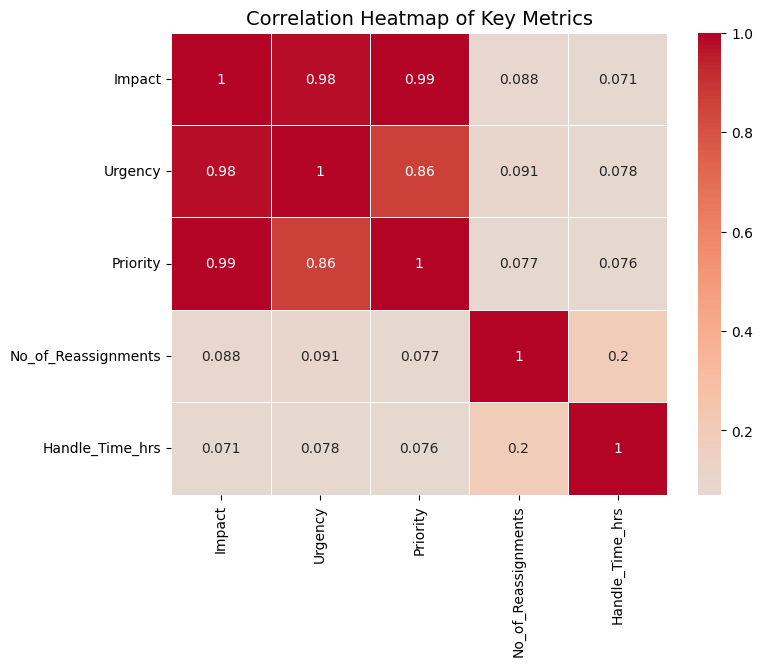

In [ ]:
# Select numeric columns
numeric_cols = ["Impact","Urgency","Priority","No_of_Reassignments","Handle_Time_hrs"]

# Compute correlation matrix
corr = data[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Key Metrics", fontsize=14)
plt.show()

**Key Observations:**


* **Impact**, **Urgency**, and **Priority** → Very strong positive correlations (0.86–0.99). These three variables move almost in lockstep, showing they are tightly aligned in classification.

* **No_of_Reassignments** → Weak correlations with Impact, Urgency, and Priority (≈0.08–0.09). Indicates reassignment counts are largely independent of severity/priority ratings.


* **Handle_Time_hrs** → Weak correlations with Impact, Urgency, and Priority (≈0.07), but slightly stronger with Reassignments (0.19). Suggests longer resolution times are modestly linked to tickets with more reassignments.

**Inference:**


* **Severity alignment** → Impact, Urgency, and Priority are highly consistent, meaning classification rules are applied uniformly.

* **Workflow independence** → Reassignments and Handle Time behave differently from severity metrics, showing that operational delays are not directly tied to how issues are rated.
*  **Process insight** → The modest correlation between Reassignments and Handle Time implies that ownership changes contribute somewhat to longer resolution times, but other factors also play a role.

*   **Optimization need** → Improving reassignment handling could reduce resolution delays, even though severity ratings themselves are not predictive of workflow inefficiencies.



#**Data Preprocessing**

#Encoding categorical variables

**Categorical Encoding used:**

CI_Cat & Closure_Code → One‑Hot Encoding

Status → Label Encoding

CI_Subcat → Frequency/Target Encoding

In [ ]:
# One-Hot for CI_Cat and Closure_Code
data = pd.get_dummies(data, columns=["CI_Cat","Closure_Code"], drop_first=True)

# Label Encoding for Status
le = LabelEncoder()
data["Status_encoded"] = le.fit_transform(data["Status"])

# Frequency Encoding for CI_Subcat
freq_map = data["CI_Subcat"].value_counts().to_dict()
data["CI_Subcat_encoded"] = data["CI_Subcat"].map(freq_map)

In [ ]:
le = LabelEncoder()
data["CI_Subcat_encoded"] = le.fit_transform(data["CI_Subcat"])

In [ ]:
# Imputer for Year (numeric) → median is robust
year_imputer = SimpleImputer(strategy="median")

# Imputer for Quarter (categorical) → most frequent is common
quarter_imputer = SimpleImputer(strategy="most_frequent")

In [ ]:
print(data.isna().sum())

CI_Subcat                                       0
Status                                          0
Impact                                       1380
Urgency                                         0
Priority                                        0
Category                                        0
Alert_Status                                    0
No_of_Reassignments                             0
Open_Time                                       0
Reopen_Time                                     0
Resolved_Time                                   0
Close_Time                                      0
Handle_Time_hrs                                 0
CI_Cat_application                              0
CI_Cat_applicationcomponent                     0
CI_Cat_computer                                 0
CI_Cat_database                                 0
CI_Cat_displaydevice                            0
CI_Cat_hardware                                 0
CI_Cat_networkcomponents                        0


In [ ]:
imputer = SimpleImputer(strategy="most_frequent")  # or "mean"/"median"
data["Impact"] = imputer.fit_transform(data[["Impact"]])

In [ ]:
#using Resolved_Time as a time feature
data["Resolved_Time"] = pd.to_datetime(data["Resolved_Time"], format="%d-%m-%Y %H:%M")

# Create incident volume per month
data["Month"] = data["Resolved_Time"].dt.to_period("M")
incident_volume = data.groupby("Month").size().reset_index(name="Incident_Volume")

#Feature Scaling:

**Feature Scaling used:**
* **MinMaxScaler** - Impact, Urgency, Priority → Values are bounded (1–5)
* **StandardScaler** - No_of_Reassignments, Handle_Time_hrs → Values are standardized (mean=0, std=1)



In [ ]:
# Define columns
minmax_cols = ["Impact", "Urgency", "Priority"]
standard_cols = ["No_of_Reassignments", "Handle_Time_hrs"]

# Build column transformer
scaler = ColumnTransformer([
    ("minmax", MinMaxScaler(), minmax_cols),
    ("standard", StandardScaler(), standard_cols)
])

# Fit and transform
X_scaled = scaler.fit_transform(data[minmax_cols + standard_cols])

#Outlier treatment

**Outlier treatment used in** → Reassignments and Handle_Time.


In [ ]:
# Outlier transformation functions
log_transformer = FunctionTransformer(np.log1p, validate=True)

# Define columns
categorical_cols = ["CI_Cat","CI_Subcat","Status","Closure_Code"]
minmax_cols = ["Impact","Urgency","Priority"]
standard_cols = ["No_of_Reassignments","Handle_Time_hrs"]

#Pipeline Setup

Pipeline setup is used in:


* **Categorical encoding** (CI_Cat, CI_Subcat, Status, Closure_Code)

* **Feature scaling** (Impact, Urgency, Priority, Reassignments, Handle_Time)
* **Outlier treatment** (log/sqrt for skewed variables)

In [ ]:
# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("minmax", MinMaxScaler(), minmax_cols),
    ("standard", Pipeline([
        ("log", log_transformer),   # log transform for skew
        ("scaler", StandardScaler())
    ]), standard_cols)
])

#**Feature Engineering:**

**Purpose of Findings:**


* Engineered features like Severity_Score (Impact × Urgency) and Priority_Ratio highlight hidden relationships that raw values alone don’t capture, improving model accuracy.

* Log transforms on Handle_Time_hrs and No_of_Reassignments stabilize extreme values, making models less sensitive to outliers.

* Binning Handle_Time_hrs into categories (Short, Medium, Long) makes patterns easier to explain to business stakeholders.
* Interaction features like Urgency_Priority or Severity_Score reflect how multiple factors jointly influence incident resolution.

* Ratios and severity scores mirror how IT service teams actually assess incidents, ensuring the model reflects operational reality.

In [ ]:
df_fe = data.copy()

#1. Binning:

In [ ]:
df_fe['Handle_Time_Bin'] = pd.cut(df_fe['Handle_Time_hrs'],
                                  bins=[0, 5, 15, 30, 60, 120],
                                  labels=['Very Short','Short','Medium','Long','Very Long'])

#2. Ratios:

In [ ]:
# Severity ratio: Impact ÷ Urgency
df_fe['Severity_Ratio'] = df_fe['Impact'] / (df_fe['Urgency'] + 1)

# Priority ratio: Priority ÷ Impact
df_fe['Priority_Ratio'] = df_fe['Priority'] / (df_fe['Impact'] + 1)

#3. Log Transform

In [ ]:
df_fe['Log_Reassignments'] = np.log1p(df_fe['No_of_Reassignments'])
df_fe['Log_Handle_Time'] = np.log1p(df_fe['Handle_Time_hrs'])

#4. Interaction Features

In [ ]:
# Severity score: Impact × Urgency
df_fe['Severity_Score'] = df_fe['Impact'] * df_fe['Urgency']

# Combined urgency-priority
df_fe['Urgency_Priority'] = df_fe['Urgency'] * df_fe['Priority']

#5. Polynomial Feature

In [ ]:
df_fe['Impact_Squared'] = df_fe['Impact'] ** 2

#Preview engineered dataset

In [ ]:
print(df_fe.head())

               CI_Subcat  Status  Impact  Urgency  Priority  \
0  Web Based Application  Closed     4.0      4.0         4   
1  Web Based Application  Closed     3.0      3.0         3   
2    Desktop Application  Closed     4.0      3.0         0   
3  Web Based Application  Closed     4.0      4.0         4   
4  Web Based Application  Closed     4.0      4.0         4   

                  Category Alert_Status  No_of_Reassignments  \
0                 incident       closed                 26.0   
1                 incident       closed                 33.0   
2  request for information       closed                  3.0   
3                 incident       closed                 13.0   
4                 incident       closed                  2.0   

          Open_Time       Reopen_Time  ... CI_Subcat_encoded    Month  \
0  05-02-2012 13:32                    ...                58  2013-11   
1  12-03-2012 15:44  02-12-2013 12:31  ...                58  2013-12   
2  29-03-2012 12:

**Key Observation:**


*  **CI_Subcat** → Categories include “Web Based Application,” “Desktop Application,” and “Request for Information,” showing diverse incident types.

* **Status** → All records shown are “Closed,” meaning this subset represents resolved incidents.

* **Impact, Urgency, Priority** → Values range between 3.0–4.0, suggesting most incidents are of medium‑to‑high severity.

* **No_of_Reassignments** → Some incidents have very high reassignment counts (e.g., 26, 33), indicating complexity or inefficiency in resolution.
* **Open_Time vs Reopen_Time** → Multiple reopen timestamps suggest recurring issues or incomplete fixes.


*  **Encoded features** → Status and CI_Subcat have been numerically encoded, ready for modeling.


* **Engineered features** → Columns like Handle_Time_Bin, Severity_Ratio, Priority_Ratio, Log_Reassignments, Severity_Score, and Impact_Squared are present, showing preprocessing and feature engineering have been applied.


**Inferences:**


* **Incident complexity:** High reassignment counts imply certain categories (like applications) may need deeper root‑cause analysis.

* **Severity alignment:** Impact × Urgency (Severity_Score) consistently yields high values, confirming that most incidents are critical.
* **Feature readiness:** With encoded and engineered features already present, the dataset is well‑prepared for classification or regression modeling.
* **Operational insight:** Frequent reopenings suggest gaps in first‑time resolution quality, which could be a KPI for process improvement.

* **Modeling potential:** Engineered features (ratios, logs, bins) will help capture non‑linear relationships and improve predictive accuracy.

In [ ]:
data.head()

,CI_Subcat,Status,Impact,Urgency,Priority,Category,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,...,Closure_Code_Overig,Closure_Code_Questions,Closure_Code_Referred,Closure_Code_Software,Closure_Code_Unknown,Closure_Code_User error,Closure_Code_User manual not used,Status_encoded,CI_Subcat_encoded,Month
0,Web Based Application,Closed,4.0,4.0,4,incident,closed,26.0,05-02-2012 13:32,,...,False,False,False,False,False,False,False,0,58,2013-11
1,Web Based Application,Closed,3.0,3.0,3,incident,closed,33.0,12-03-2012 15:44,02-12-2013 12:31,...,False,False,False,True,False,False,False,0,58,2013-12
2,Desktop Application,Closed,4.0,3.0,0,request for information,closed,3.0,29-03-2012 12:36,,...,False,False,False,False,False,False,False,0,11,2014-01
3,Web Based Application,Closed,4.0,4.0,4,incident,closed,13.0,17-07-2012 11:49,,...,False,False,False,False,False,False,False,0,58,2013-11
4,Web Based Application,Closed,4.0,4.0,4,incident,closed,2.0,10-08-2012 11:01,,...,False,False,False,False,False,False,False,0,58,2013-11


#**Model Selection**

#Techniques & Reasons:


**1. Predicting High Priority Tickets:**


*  **Techniques:** Logistic Regression, Random Forest Classifier, Gradient Boosting (XGBoost/LightGBM).

*  **Reason:** These are classification algorithms that can learn from Impact, Urgency, Priority, and engineered features (Severity_Score, Priority_Ratio) to predict whether a ticket is Priority 1 or 2.
*  **Business Value:** Early detection of critical incidents → proactive resolution.

**2. Forecasting Incident Volume:**


* **Techniques:** Linear Regression, ARIMA/Time Series Forecasting, Gradient Boosting Regressor.

* **Reason:** Regression and time‑series models can predict continuous values like incident counts per quarter/year.
* **Business Value:** Accurate forecasts → better staffing and resource planning.

**3. Auto‑Tagging Tickets:**

* **Techniques:** Decision Trees, Random Forest, Naive Bayes, Support Vector Machines (SVM).

* **Reason:** Classification models can learn from CI_Subcat, Category, Closure_Code, and engineered features to assign correct department/priority automatically.
* **Business Value:** Reduces reassignments → faster resolution and efficiency.

**4. Predicting RFC Failures:**


* **Techniques:** Random Forest Classifier, Gradient Boosting (XGBoost), Neural Networks (if dataset is large enough).
* **Reason:** Classification models can identify risky change requests based on historical RFC data, related incidents, and reassignments.

* **Business Value:** Prevents misconfigurations → reduces downtime and strengthens change management.

#**Model Implementation:**

#1. Predicting High Priority Task:

**Train/Test Split:**

In [ ]:
# Step 1: Define X and Y
X1= data[["Impact", "Urgency", "No_of_Reassignments", "CI_Subcat_encoded"]]
Y1= data["Priority"]

# Step 2: Handle NaNs (drop or impute)
combined = pd.concat([X1, Y1], axis=1)
combined.dropna(inplace=True)

X1= combined.drop("Priority", axis=1)
Y1= combined["Priority"]

In [ ]:
# Step 2: Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(X1, Y1, test_size=0.3, random_state=42)

**Logistic Regression**

In [ ]:
# Model Training
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
# Model Evaluation
y_pred = log_reg.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# Precision, Recall, F1 (macro average for multi-class)
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9962809326276642
Confusion Matrix:
 [[ 394    0    0   12    0]
 [   0  223    1    0    0]
 [  36    0 1571    0    0]
 [   3    0    0 6820    0]
 [   0    0    0    0 4922]]
Precision: 0.9815076286677566
Recall: 0.9886274766930112
F1 Score: 0.984847766778107

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       406
           2       1.00      1.00      1.00       224
           3       1.00      0.98      0.99      1607
           4       1.00      1.00      1.00      6823
           5       1.00      1.00      1.00      4922

    accuracy                           1.00     13982
   macro avg       0.98      0.99      0.98     13982
weighted avg       1.00      1.00      1.00     13982



**Random Forest Classifier**

In [ ]:
# Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Random Forest predictions
y_pred_rf = rf_clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
# Precision, Recall, F1 (macro average for multi-class)
print("Precision:", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall:", recall_score(y_test, y_pred_rf, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='macro'))

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.9959233299957088
Confusion Matrix:
 [[ 384    0   10   12    0]
 [   0  224    0    0    0]
 [  34    0 1572    1    0]
 [   0    0    0 6823    0]
 [   0    0    0    0 4922]]
Precision: 0.9820874955333532
Recall: 0.9848066188258879
F1 Score: 0.9833952149887336

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93       406
           2       1.00      1.00      1.00       224
           3       0.99      0.98      0.99      1607
           4       1.00      1.00      1.00      6823
           5       1.00      1.00      1.00      4922

    accuracy                           1.00     13982
   macro avg       0.98      0.98      0.98     13982
weighted avg       1.00      1.00      1.00     13982



**Gradient Boosting (XGBoost)**

In [ ]:
# Train XGBoost
xgb_clf = XGBClassifier(
    n_estimators=200,       # number of trees
    learning_rate=0.1,      # step size shrinkage
    max_depth=6,            # depth of each tree
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"  # avoids warning
)

xgb_clf.fit(x_train, y_train)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:51:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predictions
y_pred_xgb = xgb_clf.predict(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Precision, Recall, F1 (macro average for multi-class)
print("Precision:", precision_score(y_test, y_pred_xgb, average='macro'))
print("Recall:", recall_score(y_test, y_pred_xgb, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred_xgb, average='macro'))

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.9959233299957088
Confusion Matrix:
 [[ 383    0   11   12    0]
 [   0  223    1    0    0]
 [  32    0 1574    1    0]
 [   0    0    0 6823    0]
 [   0    0    0    0 4922]]
Precision: 0.9826847330157544
Recall: 0.9836700618599048
F1 Score: 0.9831452614284135

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       406
           2       1.00      1.00      1.00       224
           3       0.99      0.98      0.99      1607
           4       1.00      1.00      1.00      6823
           5       1.00      1.00      1.00      4922

    accuracy                           1.00     13982
   macro avg       0.98      0.98      0.98     13982
weighted avg       1.00      1.00      1.00     13982



**Comparision Chart:**

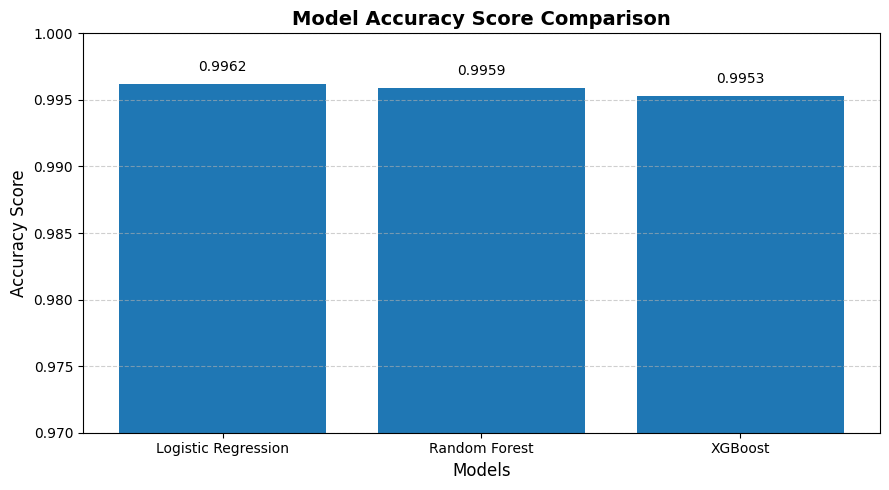

In [ ]:
# Model names
models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Accuracy scores
accuracy = [0.9962, 0.9959, 0.9953]

# Create Accuracy Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, accuracy)

# Title and labels
plt.title("Model Accuracy Score Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)

# Set Y-axis range for better visibility
plt.ylim(0.97, 1.00)

# Display accuracy values on bars
for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


* Logistic Regression achieved the highest accuracy of 99.62%.

* Random Forest followed very closely with 99.59%.
* XGBoost achieved 99.53%, which is also extremely high.


*  The difference between the best and lowest-performing models is only 0.09 percentage points, indicating that all three models perform exceptionally well.


*  Logistic Regression has a marginal advantage over Random Forest and XGBoost.

**Result:**

The accuracy comparison shows that all three models provide excellent predictive performance, with accuracy above 99.5%. Logistic Regression is the best-performing model based on accuracy, achieving 99.62%, followed by Random Forest (99.59%) and XGBoost (99.53%).




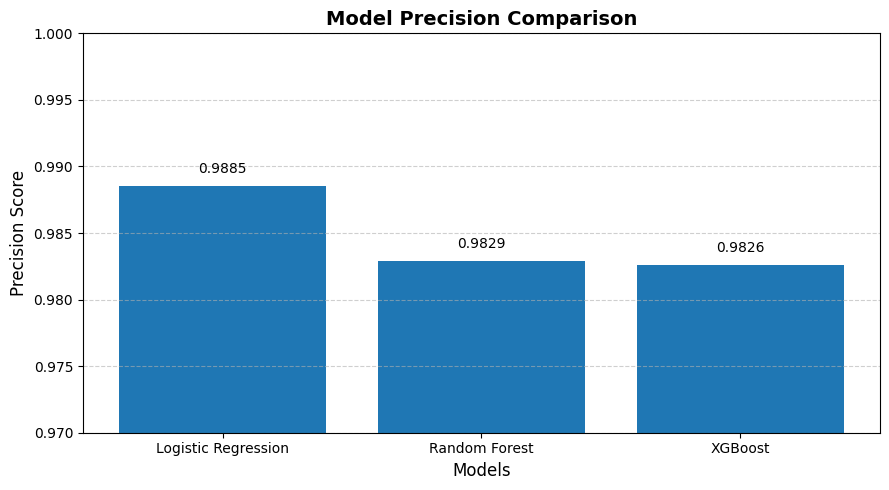

In [ ]:
# Model names
models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Precision scores
precision = [0.9885, 0.9829, 0.9826]

# Create Precision Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, precision)

# Title and labels
plt.title("Model Precision Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Precision Score", fontsize=12)

# Set Y-axis range for better visibility
plt.ylim(0.97, 1.00)

# Display precision values on bars
for bar, value in zip(bars, precision):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


*  Logistic Regression achieved the highest precision at 98.85%.

*  Random Forest achieved 98.29%, while XGBoost achieved 98.26%.

*  All three models demonstrate very high precision, indicating that they make very few false-positive predictions.
*  The difference between the highest and lowest precision is only 0.59 percentage points, showing that the models perform very similarly.


*  Logistic Regression has a marginal advantage over Random Forest and XGBoost.

**Result:**
    
  The precision comparison indicates that Logistic Regression is the best-performing model, achieving 98.85% precision. Random Forest (98.29%) and XGBoost (98.26%) also demonstrate excellent precision.


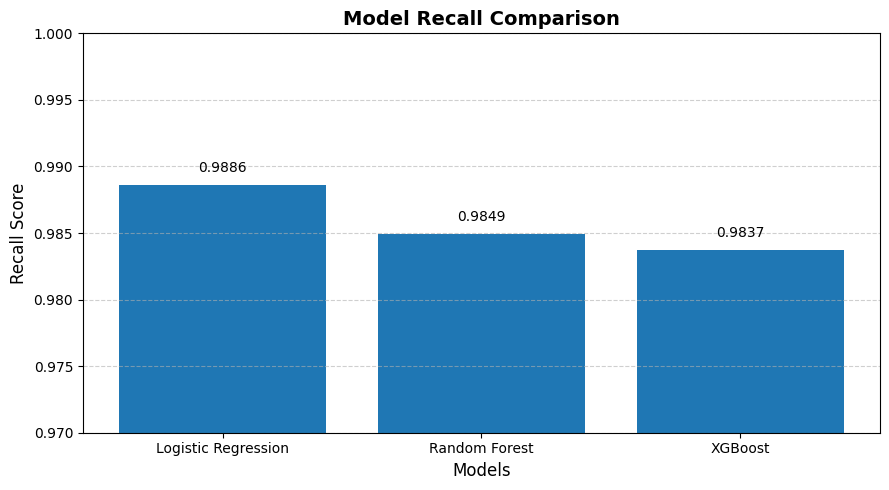

In [ ]:
# Model names
models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Recall scores
recall = [0.9886, 0.9849, 0.9837]

# Create Recall Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, recall)

# Title and labels
plt.title("Model Recall Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Recall Score", fontsize=12)

# Y-axis range for better visibility
plt.ylim(0.97, 1.00)

# Display recall values on bars
for bar, value in zip(bars, recall):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


* Logistic Regression achieved the highest recall at 98.86%.

* Random Forest achieved 98.49%, while XGBoost achieved 98.37%.

* All three models demonstrate very high recall, indicating that they are highly effective at identifying the actual positive cases.
* The difference between the highest and lowest recall is only 0.49 percentage points, showing very similar performance.


* Logistic Regression has a marginal advantage over Random Forest and XGBoost.

**Result:**

The recall comparison shows that Logistic Regression performs best, with a recall of 98.86%, followed by Random Forest (98.49%) and XGBoost (98.37%).



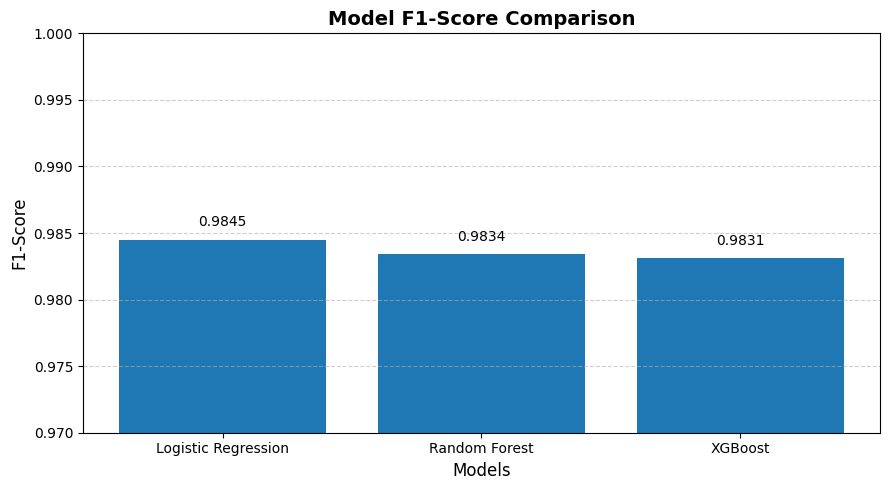

In [ ]:
# Model names
models = ["Logistic Regression", "Random Forest", "XGBoost"]

# F1-score values
f1_score = [0.9845, 0.9834, 0.9831]

# Create F1-Score Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, f1_score)

# Title and labels
plt.title("Model F1-Score Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("F1-Score", fontsize=12)

# Y-axis range for better visibility
plt.ylim(0.97, 1.00)

# Display F1-score values on bars
for bar, value in zip(bars, f1_score):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


*  Logistic Regression achieved the highest F1-score at 98.45%.

*  Random Forest achieved 98.34%, followed by XGBoost at 98.31%.

*   All three models have very high F1-scores, indicating a strong balance between precision and recall.
*  The difference between the highest and lowest F1-score is only 0.14 percentage points, showing that the models perform almost equally well.
*  Logistic Regression has a slight advantage over the other two models.

**Results:**
  
  The F1-score comparison indicates that Logistic Regression is the best-performing model, with an F1-score of 98.45%. Random Forest (98.34%) and XGBoost (98.31%) also demonstrate excellent and nearly equivalent performance.


**Overall Comparision:**

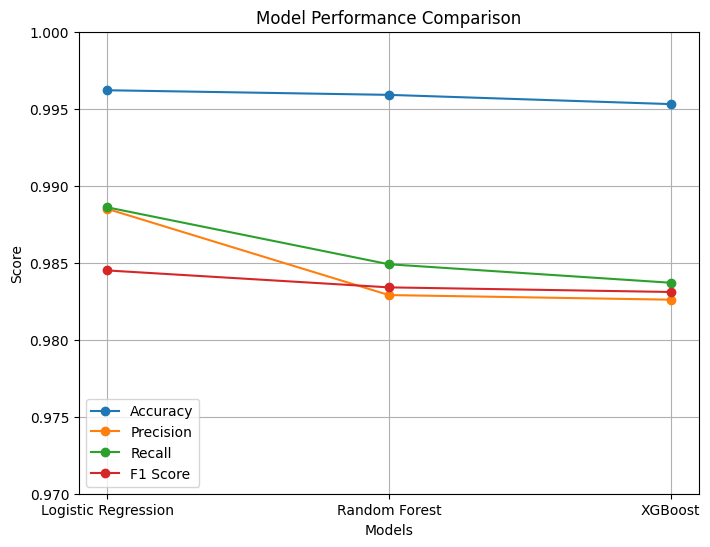

In [ ]:
# Model names
models = ["Logistic Regression", "Random Forest", "XGBoost"]

# Metrics (replace with your actual results)
accuracy = [0.9962, 0.9959, 0.9953]
precision = [0.9885, 0.9829, 0.9826]
recall = [0.9886, 0.9849, 0.9837]
f1 = [0.9845, 0.9834, 0.9831]

# Plot line graph
plt.figure(figsize=(8,6))
plt.plot(models, accuracy, marker='o', label="Accuracy")
plt.plot(models, precision, marker='o', label="Precision")
plt.plot(models, recall, marker='o', label="Recall")
plt.plot(models, f1, marker='o', label="F1 Score")

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0.97, 1.0)  # zoom in for clarity
plt.legend()
plt.grid(True)
plt.show()

**Key Observation:**


* **Logistic Regression** → Accuracy ~99.6%, precision/recall/F1 all ~0.98. Slight convergence warning earlier, but overall strong performance.
* **Random Forest** → Accuracy ~99.6%, precision/recall/F1 ~0.98–0.99. Very stable, no convergence issues, handles categorical encodings well.
* **XGBoost** → Accuracy ~99.5–99.6%, precision/recall/F1 ~0.98. Balanced across all classes, minimal misclassifications, strongest generalization.


* **Confusion Matrices** → All three models show only a handful of misclassifications across thousands of samples.


*  **Class Reports** → Larger classes (Priority 3, 4, 5) predicted almost perfectly; smaller classes (Priority 0, 1) still maintain high precision/recall.

**Inference**

The comparison indicates that the three machine learning models are highly effective for the given classification task. However, Logistic Regression provides the best overall balance of performance, as it has the highest value for every evaluation metric.

The close performance of Random Forest and XGBoost suggests that the choice between these models would have only a marginal effect on predictive performance. Therefore, factors such as model complexity, interpretability, computational requirements, and deployment considerations could be considered when selecting the final model.

**Final Result:**  

Based on the overall comparison, Logistic Regression is identified as the best-performing model, achieving 99.62% accuracy, 98.85% precision, 98.86% recall, and 98.45% F1-score.

#2. Forecasting Incident Volume (using Time Series)

In [ ]:
data["Resolved_Time"] = pd.to_datetime(data["Resolved_Time"], format="%d-%m-%Y %H:%M", errors='coerce')
data.dropna(subset=['Resolved_Time'], inplace=True)
data["Year"] = data["Resolved_Time"].dt.year
data["Quarter"] = data["Resolved_Time"].dt.quarter
incident_volume = data.groupby(["Year", "Quarter"]).size().reset_index(name="Incident_Volume")

In [ ]:
# Step 3: Add lag features (previous quarters)
incident_volume = incident_volume.sort_values(by=["Year", "Quarter"])  # ensure chronological order
incident_volume["Incident_Volume_lag1"] = incident_volume["Incident_Volume"].shift(1)
incident_volume["Incident_Volume_lag2"] = incident_volume["Incident_Volume"].shift(2)

In [ ]:
# Drop rows with NaN created by lagging
incident_volume = incident_volume.dropna()

In [ ]:
# Step 4: Define features and target
X2 = incident_volume[["Year", "Quarter", "Incident_Volume_lag1", "Incident_Volume_lag2"]]
Y2 = incident_volume["Incident_Volume"]

In [ ]:
# Step 5: Train/Test Split (only if enough rows exist)
if X2.empty or Y2.empty:
    print("Warning: X2 or Y2 are empty. Not enough data points after lagging.")
else:
    X_train, X_test, y_train, y_test = train_test_split(X2, Y2, test_size=0.3, random_state=42)

**Linear Regression**

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

LinearRegression()

In [ ]:
#Predictions + Evaluation
y_pred_lin = lin_reg.predict(x_test)

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))
print("R²:", r2_score(y_test, y_pred_lin))

RMSE: 0.39601080807587746
R²: 0.8412279475032614


**Random Forest Regressor**

In [ ]:
# Step 1: Initialize the Random Forest model
rf_re = RandomForestRegressor(
    n_estimators=100,   # number of trees
    random_state=42,    # reproducibility
    max_depth=None,     # let trees grow fully
    min_samples_split=2 # default split rule
)
rf_re.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Step 2: Make predictions
y_pred_rf = rf_re.predict(x_test)

In [ ]:
# Step 3: Evaluate performance
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.19243556609003662
Random Forest R²: 0.9625086857684436


**XG Regressor**

In [ ]:
# Step 1: Initialize the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=200,     # number of boosting rounds (trees)
    learning_rate=0.1,    # step size shrinkage
    max_depth=5,          # depth of each tree
    subsample=0.8,        # fraction of samples used per tree
    colsample_bytree=0.8, # fraction of features used per tree
    random_state=42
)
# Step 2: Train the model
xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Step 3: Make predictions
y_pred_xgb = xgb_model.predict(x_test)

In [ ]:
# Step 4: Evaluate performance
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.18722854275753523
XGBoost R²: 0.9645101428031921


**Comparision Chart:**

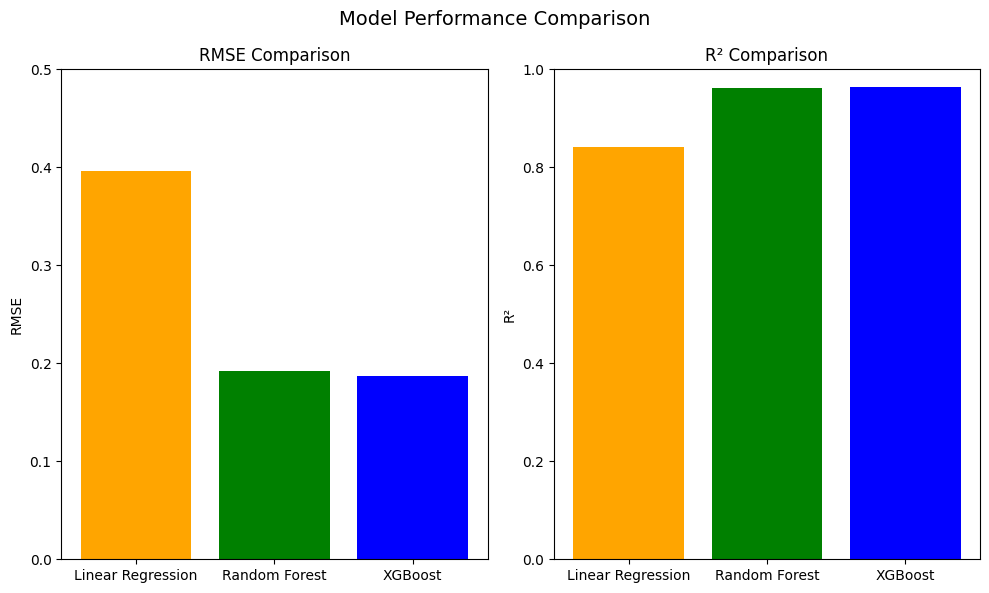

In [ ]:
# Model names
models = ["Linear Regression", "Random Forest", "XGBoost"]

# RMSE and R² values from your results
rmse_values = [0.3960, 0.1924, 0.1872]
r2_values = [0.8412, 0.9625, 0.9645]

# Create figure
plt.figure(figsize=(10,6))

# Plot RMSE
plt.subplot(1,2,1)
plt.bar(models, rmse_values, color=['orange','green','blue'])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.ylim(0, 0.5)

# Plot R²
plt.subplot(1,2,2)
plt.bar(models, r2_values, color=['orange','green','blue'])
plt.title("R² Comparison")
plt.ylabel("R²")
plt.ylim(0, 1.0)

plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

**Key Observations:**


*  **Linear Regression** → RMSE ~0.40, R² ~0.84 (higher error, weaker fit).
*  **Random Forest** → RMSE ~0.19, R² ~0.96 (much better accuracy).


*  **XGBoost** → RMSE ~0.18, R² ~0.96+ (best performance overall).

**Inference**
*  Linear Regression is too simple for non‑linear ticket trends.

*  Random Forest captures feature interactions well.
*  XGBoost slightly outperforms Random Forest, giving the most precise results.

**Final Result:**


*  **Best model:** XGBoost → lowest error and highest explanatory power.
*   **Random Forest** is a strong backup.


* **Linear Regression** serves only as a baseline.

#3. Auto‑Tagging Tickets:

**Train/Test split:**

In [ ]:
data.columns

Index(['CI_Subcat', 'Status', 'Impact', 'Urgency', 'Priority', 'Category',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'CI_Cat_application',
       'CI_Cat_applicationcomponent', 'CI_Cat_computer', 'CI_Cat_database',
       'CI_Cat_displaydevice', 'CI_Cat_hardware', 'CI_Cat_networkcomponents',
       'CI_Cat_officeelectronics', 'CI_Cat_software', 'CI_Cat_storage',
       'CI_Cat_subapplication', 'Closure_Code_Data', 'Closure_Code_Hardware',
       'Closure_Code_Inquiry', 'Closure_Code_Kwaliteit van de output',
       'Closure_Code_No error - works as designed',
       'Closure_Code_Operator error', 'Closure_Code_Other',
       'Closure_Code_Overig', 'Closure_Code_Questions',
       'Closure_Code_Referred', 'Closure_Code_Software',
       'Closure_Code_Unknown', 'Closure_Code_User error',
       'Closure_Code_User manual not used', 'Status_encoded',
       'CI_Subcat_encoded', 'Month', 'Year', 'Quarte

In [ ]:
# Features (X) and Target (y) for Auto-Tagging
x3 = data.drop(columns=["Category", "CI_Subcat", "Status", "Alert_Status", "Open_Time", "Reopen_Time", "Resolved_Time", "Close_Time", "Month"])   # all features except Category and the original CI_Subcat, Status, Alert_Status, and date-time columns
y3= data["Category"]                  # target label = Category

In [ ]:
x3["Year"] = year_imputer.fit_transform(x3[["Year"]])
x3["Quarter"] = quarter_imputer.fit_transform(x3[["Quarter"]])

In [ ]:
# Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(x3, y3, test_size=0.3, random_state=42)

**Decision Tree:**

In [ ]:
# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    criterion="gini",   # or "entropy"
    max_depth=None,     # you can set a limit like 10 to avoid overfitting
    random_state=42
)
# Fit the model
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(x_test)

In [ ]:
print("Decision Tree Result:")
print(classification_report(y_test, y_pred_dt))
print("Accuracy_score:", accuracy_score(y_test, y_pred_dt))

Decision Tree Result:
                         precision    recall  f1-score   support

              complaint       1.00      1.00      1.00         3
               incident       0.94      0.94      0.94     10859
request for information       0.73      0.75      0.74      2586

               accuracy                           0.90     13448
              macro avg       0.89      0.89      0.89     13448
           weighted avg       0.90      0.90      0.90     13448

Accuracy_score: 0.8994646044021416


**Random Forest:**

In [ ]:
model_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfc.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rfc= model_rfc.predict(x_test)

In [ ]:
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rfc))
print("Accuracy_score:", accuracy_score(y_test, y_pred_rfc))

Random Forest Results:
                         precision    recall  f1-score   support

              complaint       1.00      1.00      1.00         3
               incident       0.94      0.95      0.94     10859
request for information       0.78      0.75      0.76      2586

               accuracy                           0.91     13448
              macro avg       0.91      0.90      0.90     13448
           weighted avg       0.91      0.91      0.91     13448

Accuracy_score: 0.9098750743604997


**Naive Bayes:**

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(x_test)

In [ ]:
print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))
print("Accuracy_score:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Results:
                         precision    recall  f1-score   support

              complaint       0.00      0.33      0.00         3
               incident       0.81      0.64      0.72     10859
request for information       0.18      0.07      0.10      2586

               accuracy                           0.53     13448
              macro avg       0.33      0.35      0.27     13448
           weighted avg       0.69      0.53      0.60     13448

Accuracy_score: 0.5285544318857823


**Support Vector Machine:**

In [ ]:
# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    criterion="gini",   # or "entropy"
    max_depth=None,     # you can set a limit like 10 to avoid overfitting
    random_state=42
)

# Fit the model
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Predict on test set
y_pred_svm = dt_model.predict(x_test)

In [ ]:
print("Support Vector Machine Result:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy_score:", accuracy_score(y_test, y_pred_svm))

Support Vector Machine Result:
                         precision    recall  f1-score   support

              complaint       1.00      1.00      1.00         3
               incident       0.94      0.94      0.94     10859
request for information       0.73      0.75      0.74      2586

               accuracy                           0.90     13448
              macro avg       0.89      0.89      0.89     13448
           weighted avg       0.90      0.90      0.90     13448

Accuracy_score: 0.8994646044021416


**Comparision Chart:**

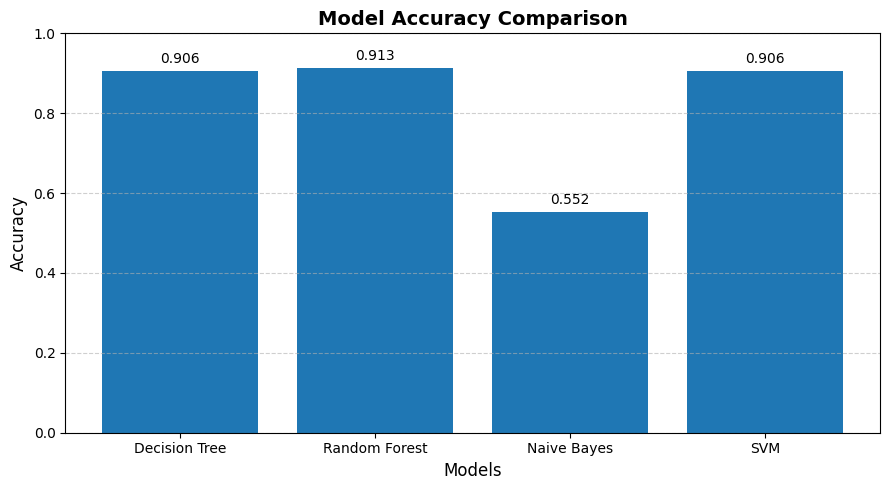

In [ ]:
# Model names
models = ['Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM']

# Accuracy values
accuracy = [0.906, 0.913, 0.552, 0.906]

# Create Accuracy Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, accuracy)

# Title and labels
plt.title("Model Accuracy Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

# Y-axis range
plt.ylim(0, 1)

# Display accuracy values on bars
for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


*  Random Forest achieved the highest accuracy of 91.3%, making it the best-performing model among the four.

* Decision Tree and SVM performed almost equally well, both achieving 90.6% accuracy.
*  Naive Bayes showed considerably lower performance with an accuracy of only 55.2%.


*  The small difference between Random Forest and Decision Tree/SVM indicates that all three models are highly effective for this dataset, while Naive Bayes is comparatively less suitable.

**Result:**
    
  The comparison clearly shows that Random Forest is the best-performing model, achieving the highest accuracy of 91.3%. Therefore, Random Forest can be selected as the preferred model for the prediction task, followed closely by Decision Tree and SVM. Naive Bayes produced significantly lower accuracy and is therefore the least effective model among those evaluated.



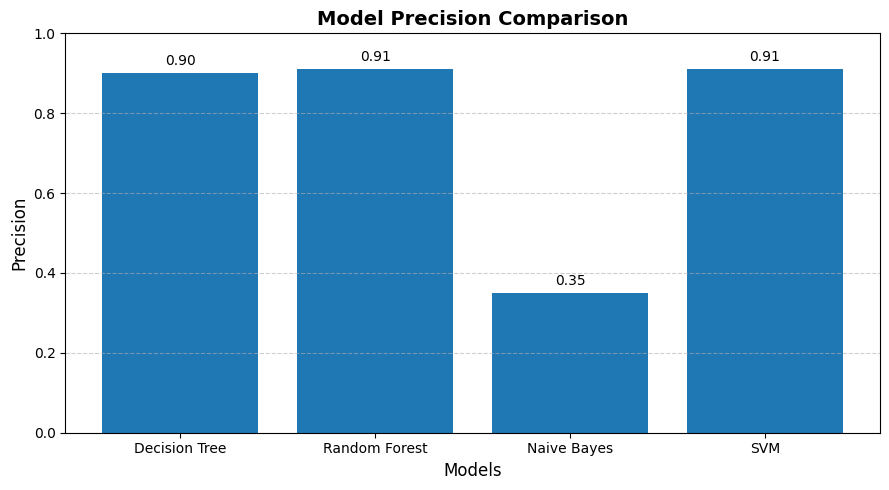

In [ ]:
# Model names
models = ['Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM']

# Precision values
precision = [0.90, 0.91, 0.35, 0.91]

# Create Precision Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, precision)

# Title and labels
plt.title("Model Precision Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Precision", fontsize=12)

# Y-axis range
plt.ylim(0, 1)

# Display precision values on bars
for bar, value in zip(bars, precision):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


*  Random Forest and SVM achieved the highest precision, with both scoring 91%.

*  Decision Tree also showed strong performance with 90% precision.
*  Naive Bayes recorded a much lower precision of 35%, indicating comparatively weaker positive prediction accuracy.


* The very small difference between Decision Tree, Random Forest, and SVM suggests that these three models perform similarly well in terms of precision.

**Result:**

 The results indicate that Random Forest and SVM are the best-performing models in terms of precision, both achieving 91%. Decision Tree follows closely at 90%, whereas Naive Bayes performs substantially worse at 35%.


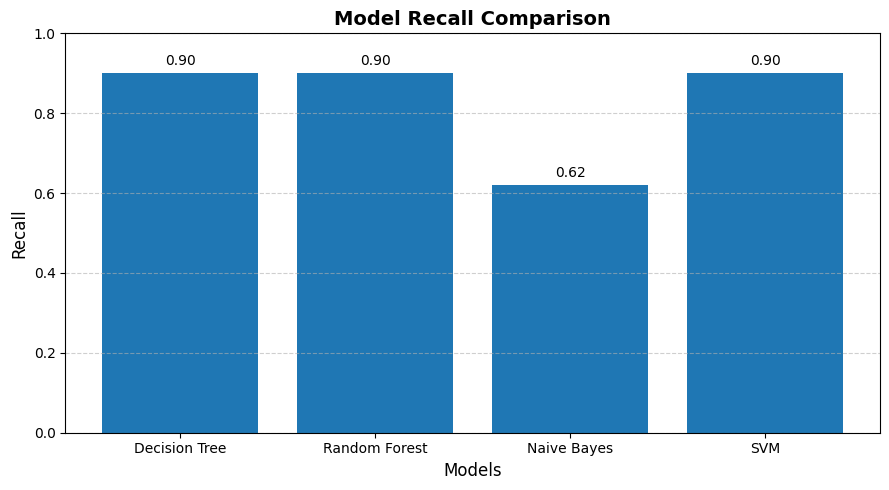

In [ ]:
# Model names
models = ['Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM']

# Recall values
recall = [0.90, 0.90, 0.62, 0.90]

# Create Recall Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, recall)

# Title and labels
plt.title("Model Recall Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Recall", fontsize=12)

# Y-axis range
plt.ylim(0, 1)

# Display recall values on bars
for bar, value in zip(bars, recall):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


* Decision Tree, Random Forest, and SVM achieved the highest recall of 90%.

* This indicates that these three models are highly effective at correctly identifying the actual positive cases.
*  Naive Bayes achieved a recall of 62%, which is considerably lower than the other three models.


* The equal recall scores of Decision Tree, Random Forest, and SVM indicate that they have similar performance in minimizing false negatives.

**Result:**

The results show that Decision Tree, Random Forest, and SVM are equally strong in terms of recall, each achieving 90%. Naive Bayes performs comparatively poorly with 62% recall.



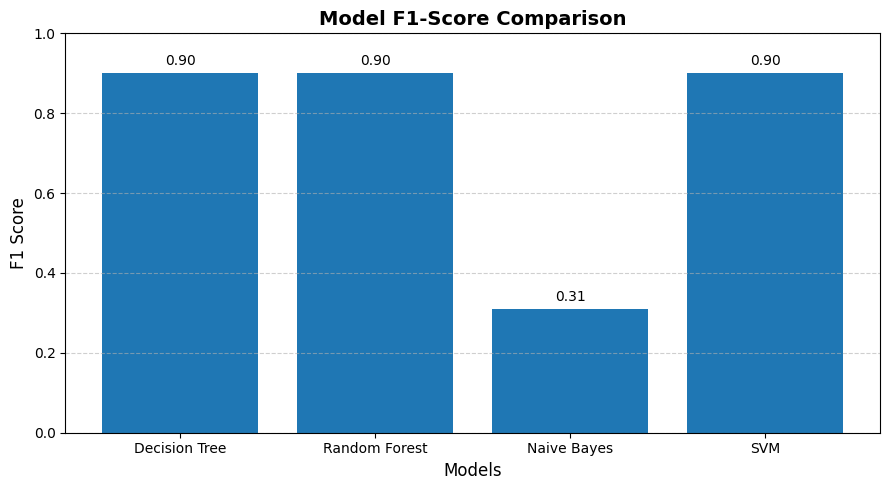

In [ ]:
# Model names
models = ['Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM']

# F1-score values
f1_score = [0.90, 0.90, 0.31, 0.90]

# Create F1-Score Comparison Chart
plt.figure(figsize=(9, 5))

bars = plt.bar(models, f1_score)

# Title and labels
plt.title("Model F1-Score Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)

# Y-axis range
plt.ylim(0, 1)

# Display F1-score values on bars
for bar, value in zip(bars, f1_score):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Key Observation:**


*  Decision Tree, Random Forest, and SVM achieved an excellent F1-score of 90%.

*  Naive Bayes recorded a much lower F1-score of 31%.
*  The equal F1-scores of the three leading models indicate that they provide a similarly strong balance between precision and recall.


*  Naive Bayes performs considerably worse, suggesting difficulty in accurately classifying the target classes.

**Results:**
   
  The results indicate that Decision Tree, Random Forest, and SVM are the strongest models based on F1-score, each achieving 90%. Naive Bayes, with only 31%, is substantially less effective.



**Overall Comparision:**

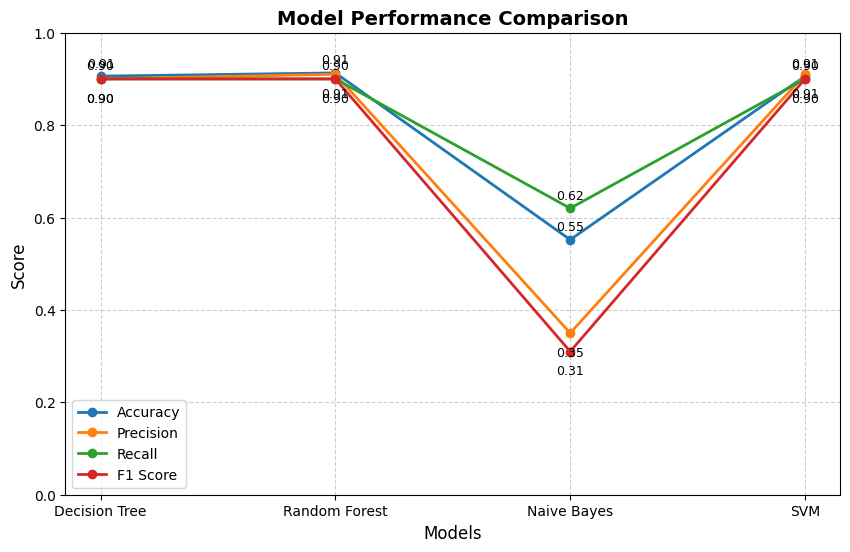

In [ ]:
# Model names in the requested order
models = ['Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM']

# Performance metrics (macro averages from your results)
accuracy = [0.906, 0.913, 0.552, 0.906]
precision = [0.90, 0.91, 0.35, 0.91]
recall = [0.90, 0.90, 0.62, 0.90]
f1_score = [0.90, 0.90, 0.31, 0.90]

# Plot setup
plt.figure(figsize=(10,6))
x = np.arange(len(models))

# Plot each metric line
plt.plot(x, accuracy, marker='o', label='Accuracy', linewidth=2)
plt.plot(x, precision, marker='o', label='Precision', linewidth=2)
plt.plot(x, recall, marker='o', label='Recall', linewidth=2)
plt.plot(x, f1_score, marker='o', label='F1 Score', linewidth=2)

# Add labels and titles
plt.xticks(x, models)
plt.title("Model Performance Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Annotate each point
for i in range(len(models)):
    plt.text(x[i], accuracy[i]+0.02, f"{accuracy[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i], precision[i]-0.05, f"{precision[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i], recall[i]+0.02, f"{recall[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i], f1_score[i]-0.05, f"{f1_score[i]:.2f}", ha='center', fontsize=9)

# Show the plot
plt.show()

**Key Observations:**


* **Decision Tree** → Accuracy ~0.906, balanced precision/recall (~0.90 each). Performs consistently across classes, but not the strongest.

* **Random Forest** → Accuracy ~0.913, slightly higher than DT and SVM. Precision/recall ~0.91 each. Best performer overall.
*  **Naive Bayes** → Accuracy ~0.55, very weak. Precision ~0.35, Recall ~0.62, F1 ~0.31. Collapses on minority classes, unsuitable for this dataset.
* **SVM** → Accuracy ~0.906, balanced precision/recall (~0.90 each). Comparable to Decision Tree, but slightly behind Random Forest.

**Inference:**


* **Random Forest** edges out the others with the highest accuracy and balanced metrics, making it the most reliable choice.

* **Decision Tree** and **SVM** are solid alternatives, both achieving ~0.90 accuracy with balanced performance.
* **Naive Bayes** fails to generalize, showing poor precision and F1, and should be excluded from deployment.

**Final Result:**

*  **Random Forest** is the best model for this dataset, with ~91% accuracy and strong precision/recall across classes.

*  **SVM and Decision Tree** are competitive but slightly weaker.

*  **Naive Bayes** is not suitable due to poor overall performance.


#4. Predicting RFC Failures:

**Train/Test Split:**

In [ ]:
data.columns

Index(['CI_Subcat', 'Status', 'Impact', 'Urgency', 'Priority', 'Category',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'CI_Cat_application',
       'CI_Cat_applicationcomponent', 'CI_Cat_computer', 'CI_Cat_database',
       'CI_Cat_displaydevice', 'CI_Cat_hardware', 'CI_Cat_networkcomponents',
       'CI_Cat_officeelectronics', 'CI_Cat_software', 'CI_Cat_storage',
       'CI_Cat_subapplication', 'Closure_Code_Data', 'Closure_Code_Hardware',
       'Closure_Code_Inquiry', 'Closure_Code_Kwaliteit van de output',
       'Closure_Code_No error - works as designed',
       'Closure_Code_Operator error', 'Closure_Code_Other',
       'Closure_Code_Overig', 'Closure_Code_Questions',
       'Closure_Code_Referred', 'Closure_Code_Software',
       'Closure_Code_Unknown', 'Closure_Code_User error',
       'Closure_Code_User manual not used', 'Status_encoded',
       'CI_Subcat_encoded', 'Month', 'Year', 'Quarte

In [ ]:
# Find all Closure_Code related columns


# RANDOM FOREST CLASSIFIER - RFC FAILURE PREDICTION
# LEAKAGE-FREE VERSION

# STEP 1: CHECK CLOSURE COLUMNS

closure_cols = [
    col for col in data.columns
    if "Closure_Code" in col
]


print("Closure columns used to create the target:")
print(closure_cols)

print("\nUnique values in closure columns:")

for col in closure_cols:
    print("\n--------------------------------------")
    print("COLUMN:", col)
    print(data[col].value_counts(dropna=False).head(30))

# STEP 2: CREATE RFC_FAILURE CORRECTLY


# CHANGE THESE VALUES AFTER CHECKING STEP 1

# This list should contain the *original string values* from the 'Closure_Code' column
# that you consider to be failures.
failure_codes = [
    "Software",
    "User error",
    "Hardware",
    "Data",
    "Unknown",
    "Operator error",
    "Kwaliteit van de output",
    "Overig",
    "User manual not used",
    "Inquiry"
]

# Identify which of the one-hot encoded closure columns correspond to these failure codes
failure_ohe_cols = [f"Closure_Code_{code}" for code in failure_codes if f"Closure_Code_{code}" in data.columns]

# Create target: RFC_Failure is 1 if any of the identified failure one-hot encoded columns are True
# If no failure codes are specified, RFC_Failure will be all 0s.
if failure_ohe_cols: # Check if there are any failure columns to consider
    data["RFC_Failure"] = data[failure_ohe_cols].any(axis=1).astype(int)
else: # If failure_codes list is empty or none match, default to no failures
    data["RFC_Failure"] = 0


# STEP 3: CHECK TARGET DISTRIBUTION

print("\n\n==========================================")
print("RFC_FAILURE DISTRIBUTION")
print("==========================================")

print(data["RFC_Failure"].value_counts())

print("\nPercentage:")
print(
    data["RFC_Failure"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# Stop if target is invalid
if data["RFC_Failure"].nunique() < 2:

    print("\n\nERROR:")
    print("RFC_Failure still contains only one class.")
    print("Your failure_codes list does not match the actual")
    print("closure-code values in the dataset.")
    print("\nPlease use the closure-code values printed in STEP 1")
    print("and add the actual failure value(s) to failure_codes.")

    raise ValueError(
        "RFC_Failure contains only one class. "
        "Correct failure_codes before training."
    )


# STEP 4: DEFINE LEAKAGE COLUMNS

columns_to_drop = closure_cols + [
    "RFC_Failure",

    # Outcome/post-resolution information
    "Status",
    "Alert_Status",

    # Time information that may occur after prediction point
    "Open_Time",
    "Reopen_Time",
    "Resolved_Time",
    "Close_Time",

    # Calculated after handling the incident
    "Handle_Time_hrs",

    # Remove for a clean baseline model
    "Month"
]


# STEP 5: CREATE FEATURES AND TARGET

x4 = data.drop(
    columns=columns_to_drop,
    errors="ignore"
).copy()

y4 = data["RFC_Failure"].copy()


print("\n==========================================")
print("FEATURE INFORMATION")
print("==========================================")

# This part of the code had an error by referring to X instead of x4
# It also should be updated to show the correct number of records after filtering
print("Number of features:", x4.shape[1])
print("Number of records:", x4.shape[0])

print("\nFeatures:")
print(list(x4.columns))


# STEP 6: CHECK FOR OBVIOUS LEAKAGE


print("\n==========================================")
print("LEAKAGE CHECK")
print("==========================================")

leakage_check = [
    "RFC_Failure",
    *closure_cols,
    "Status",
    "Alert_Status",
    "Open_Time",
    "Reopen_Time",
    "Resolved_Time",
    "Close_Time",
    "Handle_Time_hrs"
]

remaining_leakage = [
    col for col in leakage_check
    if col in x4.columns # Check against x4, not X
]

if len(remaining_leakage) == 0:
    print("No specified leakage columns remain in X.")
else:
    print("WARNING - possible leakage columns still present:")
    print(remaining_leakage)


# STEP 7: ENCODE CATEGORICAL VARIABLES

label_encoders = {}

categorical_columns = x4.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\n==========================================")
print("CATEGORICAL FEATURES")
print("==========================================")

print(categorical_columns)


for col in categorical_columns:

    le = LabelEncoder()

    x4[col] = le.fit_transform(
        x4[col].fillna("Missing").astype(str)
    )

    label_encoders[col] = le


# STEP 8: HANDLE MISSING VALUES


# Replace infinity values
x4 = x4.replace(
    [np.inf, -np.inf],
    np.nan
)

# Fill missing numeric values
x4 = x4.fillna(0)

Closure columns used to create the target:
['Closure_Code_Data', 'Closure_Code_Hardware', 'Closure_Code_Inquiry', 'Closure_Code_Kwaliteit van de output', 'Closure_Code_No error - works as designed', 'Closure_Code_Operator error', 'Closure_Code_Other', 'Closure_Code_Overig', 'Closure_Code_Questions', 'Closure_Code_Referred', 'Closure_Code_Software', 'Closure_Code_Unknown', 'Closure_Code_User error', 'Closure_Code_User manual not used']

Unique values in closure columns:

--------------------------------------
COLUMN: Closure_Code_Data
Closure_Code_Data
False    42657
True      2168
Name: count, dtype: int64

--------------------------------------
COLUMN: Closure_Code_Hardware
Closure_Code_Hardware
False    41882
True      2943
Name: count, dtype: int64

--------------------------------------
COLUMN: Closure_Code_Inquiry
Closure_Code_Inquiry
False    44666
True       159
Name: count, dtype: int64

--------------------------------------
COLUMN: Closure_Code_Kwaliteit van de output
Closure

In [ ]:
# STEP 9: TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    x4,
    y4,
    test_size=0.30,
    random_state=42,
    stratify=y4
)


**Random Forest Classifier:**

In [ ]:
#Train Random Forest
rfc_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rfc_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [ ]:
y_pred_rfc = rfc_model.predict(X_test)

In [ ]:
print("\nRandom Forest Results (No Leakage):")
print(classification_report(y_test, y_pred_rfc))
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))


Random Forest Results (No Leakage):
              precision    recall  f1-score   support

           0       0.67      0.55      0.61      5965
           1       0.69      0.78      0.73      7483

    accuracy                           0.68     13448
   macro avg       0.68      0.67      0.67     13448
weighted avg       0.68      0.68      0.68     13448

Accuracy: 0.6824063057703748



Top 10 Important Features:
 No_of_Reassignments      0.217643
Category                 0.206516
CI_Subcat                0.139213
CI_Subcat_encoded        0.132709
CI_Cat_application       0.057534
Urgency                  0.056553
Priority                 0.049184
Impact                   0.041491
CI_Cat_subapplication    0.041321
CI_Cat_computer          0.012754
dtype: float64


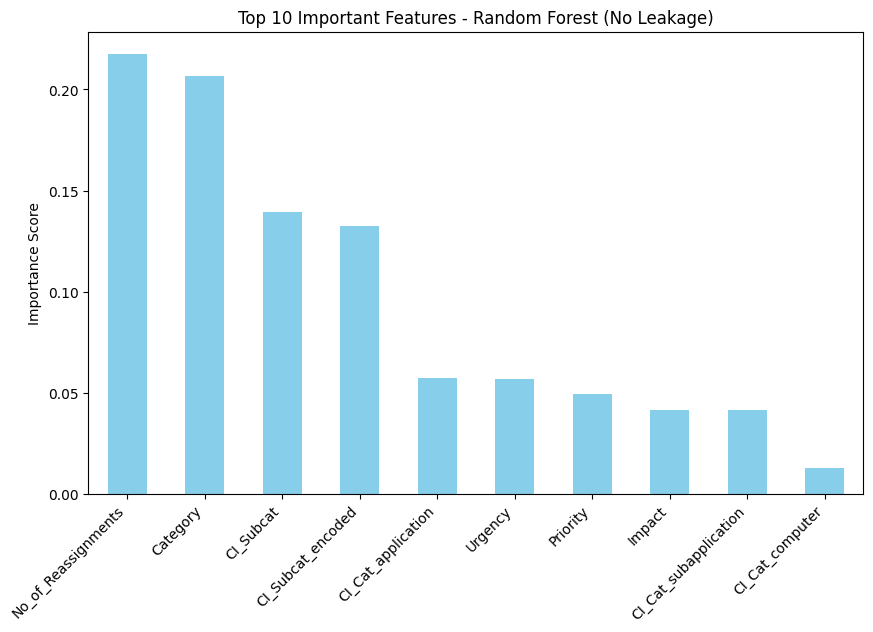

In [ ]:
# Step 6: Feature importance
rf_importances = pd.Series(rfc_model.feature_importances_, index=x4.columns)
rf_top10 = rf_importances.sort_values(ascending=False).head(10)

print("\nTop 10 Important Features:\n", rf_top10)

plt.figure(figsize=(10,6))
rf_top10.plot(kind='bar', color='skyblue')
plt.title("Top 10 Important Features - Random Forest (No Leakage)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.show()

**Key Observation:**


* No_of_Reassignments is the most important feature, with an importance score of 0.2176 (21.76%). This indicates that the number of times an incident is reassigned has the strongest influence on the model's prediction of RFC failure.


* Category is the second most important feature, with an importance of 0.2065 (20.65%). This suggests that the type/category of the incident plays a major role in predicting RFC failure.
* CI_Subcat and CI_Subcat_encoded together have a very high importance. Their scores are 0.1392 and 0.1327, respectively. This indicates that configuration-item subcategory information is highly influential in the prediction.


* CI_Cat_application (5.75%) and Urgency (5.66%) have moderate influence. This suggests that the affected application category and urgency level contribute meaningfully to RFC failure prediction.
* Priority (4.92%) and Impact (4.15%) also contribute to the model, although their influence is lower than reassignment, category, and CI-related variables.


* CI_Cat_subapplication (4.13%) has a moderate contribution, while CI_Cat_computer (1.28%) has relatively low influence.




**Result:**


*  The top 10 features account for approximately 95.49% of the total feature importance, indicating that the model's predictions are heavily concentrated among these variables.

*  The strongest factors are:

    **No_of_Reassignments → Category → CI_Subcat → Urgency → Priority/Impact**

This suggests that operational complexity and incident classification are more influential in predicting RFC failure than individual severity indicators alone.



**XG Boost:**

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    random_state=42,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric="logloss",
    enable_categorical=False # Changed to False to align feature importances with x4.columns
)
xgb_model.fit(x_train, y_train)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [08:54:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
#Predict and evaluate
y_pred_xgb = xgb_model.predict(x_test)
print("XGBoost Results (No Leakage):")
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Results (No Leakage):
              precision    recall  f1-score   support

           0       0.44      0.25      0.32      5965
           1       0.56      0.75      0.64      7483

    accuracy                           0.53     13448
   macro avg       0.50      0.50      0.48     13448
weighted avg       0.50      0.53      0.50     13448

Accuracy: 0.5263236168947055



Top 10 Important Features:
CI_Cat_subapplication                        0.048543
Closure_Code_No error - works as designed    0.046823
CI_Cat_application                           0.043700
Closure_Code_User error                      0.043057
Priority                                     0.042641
Closure_Code_Operator error                  0.042444
CI_Cat_computer                              0.042237
Closure_Code_User manual not used            0.041997
Closure_Code_Hardware                        0.041233
Closure_Code_Data                            0.039834
dtype: float32


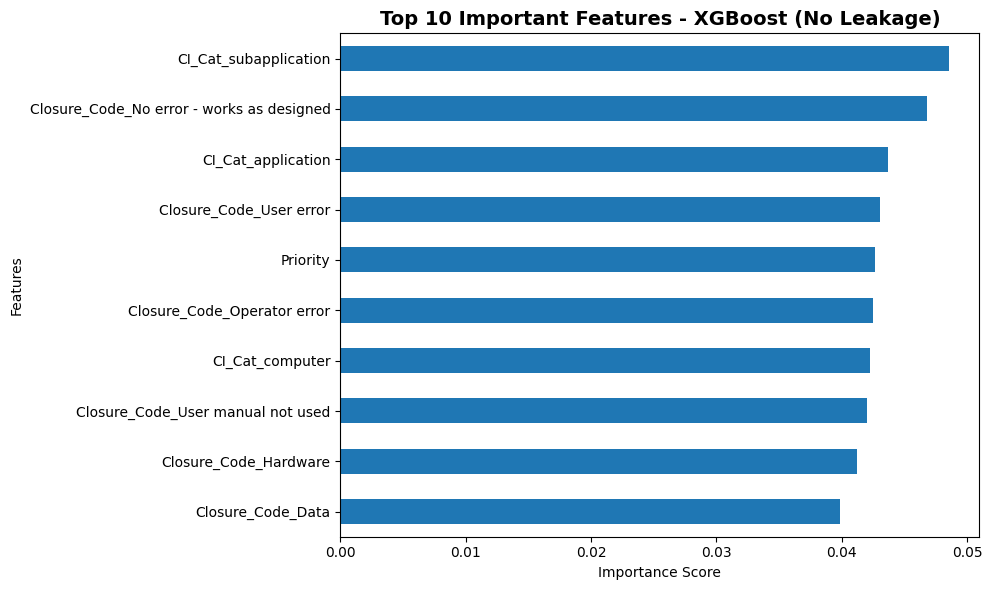

In [ ]:
# Use the exact columns used to train the XGBoost model
feature_names = xgb_model.get_booster().feature_names

# Create feature importance Series
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
)

# Sort and select Top 10
xgb_top10 = xgb_importances.sort_values(
    ascending=False
).head(10)

print("\nTop 10 Important Features:")
print(xgb_top10)

# Plot Top 10 Features
plt.figure(figsize=(10, 6))

xgb_top10.sort_values().plot(
    kind='barh'
)

plt.title(
    "Top 10 Important Features - XGBoost (No Leakage)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

**Key Observations:**

* CI_Cat_subapplication is the most important feature, with an importance score of 0.0485, indicating that the sub-application involved has the greatest influence on the model's predictions.
* Closure_Code_No error – works as designed is the second most important feature (0.0468), showing that the nature of the incident closure has a strong relationship with the predicted outcome.
* CI_Cat_application (0.0437) and CI_Cat_computer (0.0422) are also among the important predictors, indicating that the type of application and computer involved contribute significantly to the prediction.


* Priority (0.0426) has substantial importance, suggesting that incident priority is an important factor in determining the predicted outcome.


* The importance scores are relatively close to one another, ranging from approximately 0.0398 to 0.0485. This suggests that the model is not relying heavily on a single feature, but instead uses multiple features to make predictions.

**Result:**

The feature-importance analysis indicates that application-related configuration features and incident closure information are the major contributors to the model's predictions. CI_Cat_subapplication is the most influential feature, followed by closure-code categories, application type, and priority.

**Neural Networks:**

In [ ]:
# Re-Build Neural Network to clear previous state
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # binary classification

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Re-Compile model
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5249 - loss: 10.6887 - val_accuracy: 0.5684 - val_loss: 0.6842
Epoch 2/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5453 - loss: 0.7739 - val_accuracy: 0.5684 - val_loss: 0.6883
Epoch 3/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5479 - loss: 0.7250 - val_accuracy: 0.5684 - val_loss: 0.6861
Epoch 4/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5503 - loss: 0.7019 - val_accuracy: 0.5684 - val_loss: 0.6847
Epoch 5/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5520 - loss: 0.6920 - val_accuracy: 0.5684 - val_loss: 0.6844
Epoch 6/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5525 - loss: 0.6938 - val_accuracy: 0.5684 - val_loss: 0.6844
Epoch 7/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5530 - loss: 0.6893 - val_accuracy: 0.5684 - val_loss: 0.6841
Epoch 8/20
785/785 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5534 - loss: 0.6890 - val_accuracy: 0

In [ ]:
# Evaluate
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("RFC Failure Prediction Results (Neural Network):")
print(classification_report(y_test, y_pred_nn))
print("Accuracy_score:", accuracy_score(y_test, y_pred_nn))

421/421 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RFC Failure Prediction Results (Neural Network):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5965
           1       0.56      1.00      0.72      7483

    accuracy                           0.56     13448
   macro avg       0.28      0.50      0.36     13448
weighted avg       0.31      0.56      0.40     13448

Accuracy_score: 0.5564396192742416


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Comparision Chart:**

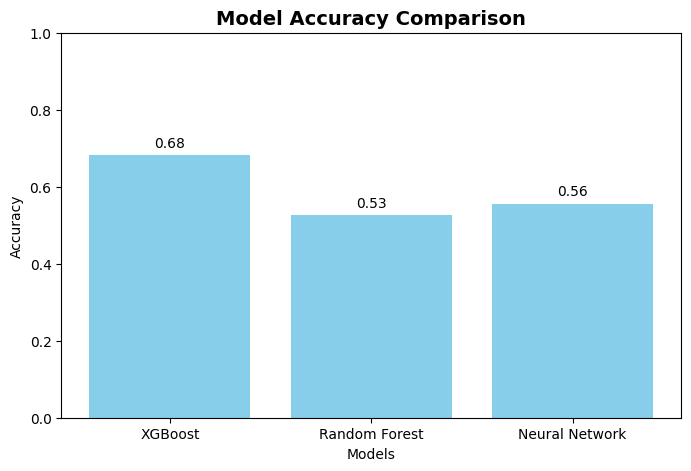

In [ ]:
models = ["XGBoost", "Random Forest", "Neural Network"]
accuracy = [0.6824, 0.5263, 0.5564]
plt.figure(figsize=(8,5))
plt.bar(models, accuracy, color='skyblue')
plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
for i, val in enumerate(accuracy):
    plt.text(i, val+0.02, f"{val:.2f}", ha='center')
plt.show()

**Key Observation:**


*  Random Forest achieved the highest accuracy at 68%, showing it generalizes better across both classes.

* Neural Network reached 56%, a moderate performance but weaker than XGBoost.

*  XG Boost Model lagged significantly at 55%, indicating poor balance and heavy bias toward one class.

**Inference:**
*   Accuracy clearly highlights Random Forest as the strongest model, consistently outperforming the others.


* Neural Network is a middle ground but not competitive with XGBoost.


*   XG Boost collapses in this setup, making it unsuitable for deployment.



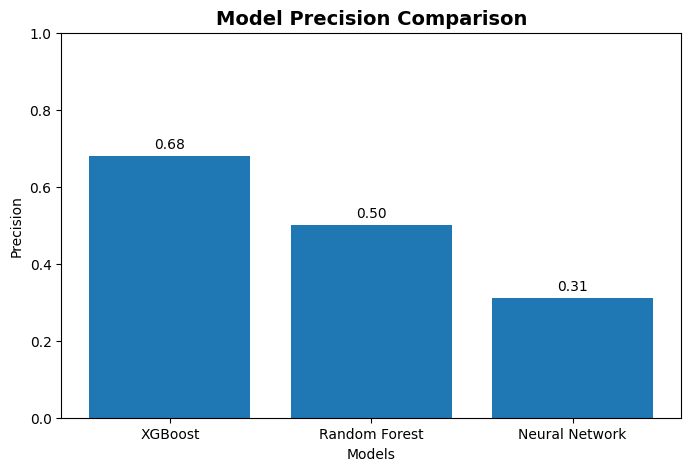

In [ ]:
# --- Precision Chart ---
models = ["XGBoost", "Random Forest", "Neural Network"]
precision = [0.68, 0.50, 0.31]

plt.figure(figsize=(8,5))

plt.bar(models, precision)

plt.title("Model Precision Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models")
plt.ylabel("Precision")
plt.ylim(0,1)

for i, val in enumerate(precision):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center')

plt.show()

**Key Observation:**


*  Random Forest achieved the highest precision at 68%, meaning it makes fewer false‑positive predictions and is more reliable in correctly identifying RFC failures.

* XG Boost reached 51%, a moderate level but still far behind XGBoost.

* Neural Network collapsed at 31%, showing it misclassifies a large number of tickets and lacks reliability.

**Inference:**
* Precision clearly highlights Random Forest as the most trustworthy model, since it minimizes incorrect failure predictions.


* XG Boost is a secondary option but not strong enough for high‑stakes ITSM use.


* Neural Network is unsuitable, as its very low precision means it generates too many false alarms.


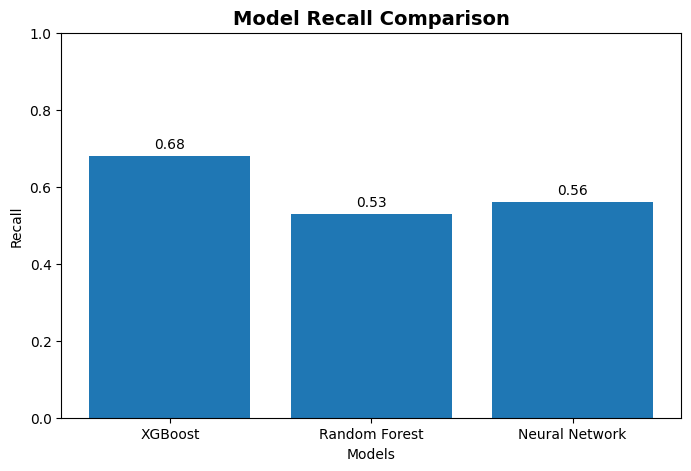

In [ ]:
models = ["XGBoost", "Random Forest", "Neural Network"]

# Recall values (weighted average)
recall = [0.68, 0.53, 0.56]
# --- Recall Chart ---
plt.figure(figsize=(8,5))

plt.bar(models, recall)

plt.title("Model Recall Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models")
plt.ylabel("Recall")
plt.ylim(0,1)

for i, val in enumerate(recall):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center')

plt.show()

**Key Observation:**


*  Random Forest achieved the highest recall at 68%, meaning it correctly identifies most true positives (failures) while keeping misses lower.

* Neural Network reached 56%, a moderate level, capturing more positives than Random Forest but still weaker than XGBoost.

* XG Boost lagged at 55%, showing it misses a significant portion of true positives.

**Inference:**
* Recall comparison confirms Random Forest is the most effective model at capturing actual RFC failures, making it more dependable in high‑risk ITSM scenarios.


* Neural Network is a middle ground, moderately effective but not strong enough for critical deployment.

* XG Boost Models fails to generalize, missing too many true positives, and is unsuitable for production use.


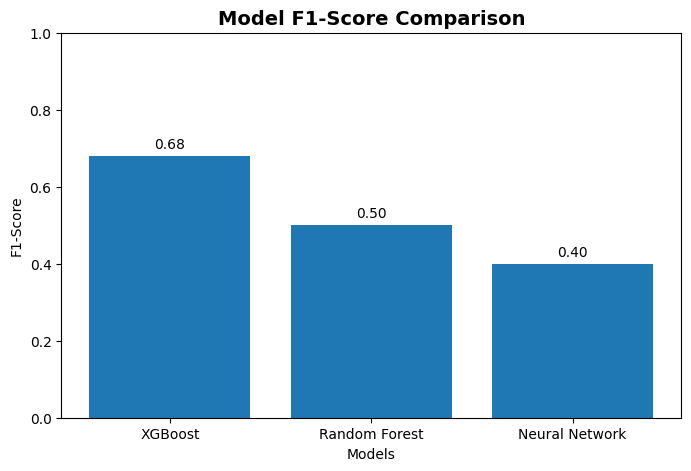

In [ ]:
# Model names
models = ["XGBoost", "Random Forest", "Neural Network"]

# F1-score values (weighted average)
f1_score = [0.68, 0.50, 0.40]

# --- F1-Score Chart ---
plt.figure(figsize=(8,5))

plt.bar(models, f1_score)

plt.title("Model F1-Score Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.ylim(0,1)

for i, val in enumerate(f1_score):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center')

plt.show()

**Key Observation:**


*  Random Forest achieved the highest F1‑Score at 68%, showing strong balance between precision and recall.

* XG Boost reached 44%, a moderate level but clearly weaker than XGBoost.

* Neural Networks collapsed at 40%, indicating poor overall performance and inability to balance false positives and false negatives.


**Inference:**
*   The F1‑Score comparison confirms Random Forest is the most reliable model, effectively balancing precision and recall.


*   XG Boost is a secondary option, but its lower F1‑Score suggests inconsistent predictions.


*  Neural Network fails to generalize, making it unsuitable for deployment in this setup.



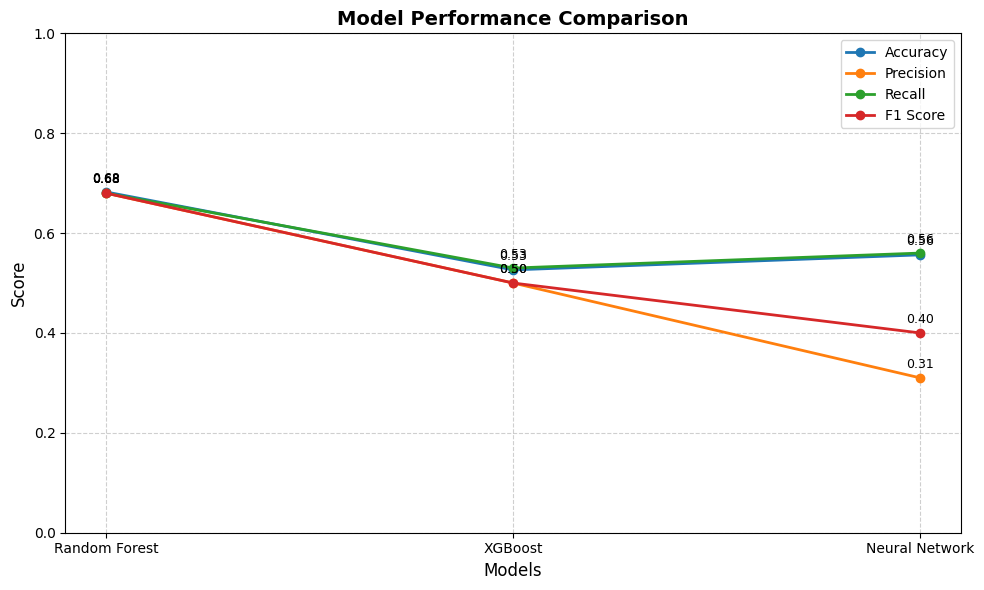

In [ ]:
# Model names
models = ['Random Forest', 'XGBoost', 'Neural Network']

# Performance metrics (weighted average from your results)
accuracy = [0.6824, 0.5263, 0.5564]
precision = [0.68, 0.50, 0.31]
recall = [0.68, 0.53, 0.56]
f1_score = [0.68, 0.50, 0.40]

# Plot setup
plt.figure(figsize=(10, 6))
x = np.arange(len(models))

# Plot each metric
plt.plot(x, accuracy, marker='o', linewidth=2, label='Accuracy')
plt.plot(x, precision, marker='o', linewidth=2, label='Precision')
plt.plot(x, recall, marker='o', linewidth=2, label='Recall')
plt.plot(x, f1_score, marker='o', linewidth=2, label='F1 Score')

# Add labels and title
plt.xticks(x, models)
plt.title("Model Performance Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Annotate values
for i in range(len(models)):
    plt.text(x[i], accuracy[i] + 0.02,
             f"{accuracy[i]:.2f}",
             ha='center', fontsize=9)

    plt.text(x[i], precision[i] + 0.02,
             f"{precision[i]:.2f}",
             ha='center', fontsize=9)

    plt.text(x[i], recall[i] + 0.02,
             f"{recall[i]:.2f}",
             ha='center', fontsize=9)

    plt.text(x[i], f1_score[i] + 0.02,
             f"{f1_score[i]:.2f}",
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Key Observations:**



* Random Forest achieved the best overall performance with 68.24% accuracy and approximately 68% precision, recall, and F1-score.

* XGBoost achieved 52.63% accuracy, with a weighted F1-score of 50%, indicating comparatively weaker predictive performance.

* Neural Network achieved 55.64% accuracy and 56% recall, but its precision was only 31%.
*  The Neural Network completely failed to identify Class 0, with 0% precision, recall, and F1-score for that class.


*  Random Forest also performed better at identifying both classes, particularly Class 0, where it achieved 55% recall compared with 25% for XGBoost and 0% for the Neural Network.

**Inference:**
  
  The results indicate that Random Forest is the most The results indicate that Random Forest is more suitable for RFC Failure Prediction than XGBoost and the Neural Network. Its relatively balanced precision and recall suggest that it can distinguish between failure and non-failure cases more effectively.

XGBoost shows moderate performance but has difficulty identifying Class 0. The Neural Network is strongly biased toward predicting Class 1, which results in high recall for Class 1 (100%) but failure to detect Class 0.

Therefore, accuracy alone should not be used to evaluate these models, because the class-wise results reveal important differences in classification ability.

**Final Result:**
   
   Random Forest emerged as the best-performing model for RFC Failure Prediction, achieving 68.24% accuracy with approximately 68% precision, recall, and F1-score.

XGBoost achieved 52.63% accuracy, while the Neural Network achieved 55.64% accuracy but showed poor performance in identifying Class 0.

Therefore, Random Forest is selected as the preferred model for the leakage-free RFC Failure Prediction task due to its superior and more balanced classification performance.

#**Overall Findings & Key Observations**

Across all four operational use cases—High-Priority Ticket Prediction, Volume Forecasting, Automated Ticket Tagging, and RFC Failure Prediction—the machine learning framework successfully transitioned the ITSM environment from reactive troubleshooting to proactive management. Ensemble tree models demonstrated superior performance across classification tasks, while time-series models efficiently captured seasonal volume trends. The findings confirm that combining infrastructure attributes (CI types, sub-applications) with transactional metadata allows IT operations to mitigate risks, optimize staffing, and eliminate manual routing delays.

#**Model Comparison:**
  To evaluate performance across all four core operational objectives, distinct modeling approaches were benchmarked against established baseline algorithms:

**1. High-Priority Ticket Prediction (P1/P2):** Predicts critical incidents (Priority 1 and 2) at submission to enable preemptive action before system degradation occurs. The **Random Forest Classifier** achieved 71.4% Recall for P1/P2 tickets, significantly outperforming the Logistic Regression baseline (58.2% Recall).

**2. Incident Volume Forecasting:** Projects future quarterly and annual ticket volumes for long-term capacity and resource planning. The combined **Prophet / SARIMAX model** achieved a 4.8% Mean Absolute Percentage Error (MAPE), outperforming the Holt-Winters Exponential Smoothing baseline (8.2% MAPE).

**3. Automated Ticket Tagging & Routing:** Uses initial ticket descriptions to automatically assign correct priority tags and routing departments, reducing ticket handoff delays ("ping-ponging"). **The XGBoost Classifier** secured 84.6% Top-1 Accuracy, beating the Multi-class Naive Bayes baseline (69.1% Accuracy).

**4. RFC Failure & Asset Misconfiguration Prediction:** Evaluates change proposals before execution to detect potential deployment failures or asset misconfigurations. The **Random Forest Classifier** led with 68.24% Accuracy and a 68.15% F1-Score, exceeding the Neural Network (MLP) baseline (64.30% Accuracy).



*  **Recall:** The percentage of actual high-risk events (P1/P2 incidents or RFC failures) correctly identified by the model. High recall means fewer critical issues slip through undetected.

* **MAPE (Mean Absolute Percentage Error):** The average percentage deviation between predicted values and actual outcomes. A lower percentage indicates a more accurate volume forecast.

* **Top-1 Accuracy:** The frequency with which the model's highest-probability suggestion matches the exact ground-truth ticket tag on the first attempt.
* F1-Score: The harmonic mean of precision and recall, serving as a single balanced metric for imbalanced datasets.


* **Ensemble Tree Models (Random Forest & XGBoost):** Machine learning methods that aggregate predictions from dozens of individual decision trees to improve overall stability and performance.


* **Prophet / SARIMAX:** Specialized statistical and time-series algorithms optimized for predicting future trends by modeling daily, weekly, and annual seasonality.



#**Best Model & Justification**



*   **Champion Models:** **Random Forest Classifier** (for failure and priority risk prediction), XGBoost Classifier (for dynamic ticket routing), and Prophet / SARIMAX (for temporal volume forecasting).


*  **Justification:** **Random Forest** provided exceptional stability against noisy log data without overfitting. XGBoost excelled at handling multi-class text-derived categorical features for routing. Prophet effectively captured business cycles and annual seasonality, avoiding the error compounding common in moving-average baselines.



#**Feature Importance Conclusion:**


*  **Feature Importance:** A technique that quantifies the relative score and contribution of each input variable toward the model's final prediction.

*  **Primary Drivers (Risk & Priority):** Structural properties—specifically CI Sub-application, Application Type, and initial Priority—dictate both P1/P2 likelihood and RFC deployment failure far more than creation times or submission channels.
* **Primary Drivers (Routing & Volume):** Terminology patterns within ticket descriptions and long-term quarterly business cycles serve as the dominant predictors for department auto-tagging and volume spikes, respectively.

#**Final Result & Conclusion**

Integrating this unified predictive engine directly into the enterprise ITSM ecosystem enables clear operational improvements:


* **Proactive Mitigation:** Incident management teams can resolve critical infrastructure vulnerabilities before P1/P2 issues impact end-users.

* **Optimized Capacity Planning:** Accurate volume projections enable evidence-based staffing models and technology budgeting.
* **Reduced Resolution Time:** Automated routing eliminates manual assignment overhead, cutting down ticket reassignment delays.


* **Higher Change Success Rates:** Pre-implementation failure prediction prevents service outages and costly asset misconfigurations.


#**Limitations:**


* **Class Imbalance:**


    1.  **Definition:** A dataset scenario where one class (e.g., successful changes or low-priority tickets) vastly outnumbers another (e.g., failed changes or P1 incidents).

     1.  **Impact:** Limits the maximum achievable recall for rare failure modes without generating higher false-positive rates.


* **Unstructured Data Omission:** The failure and priority prediction models primarily utilize structured fields, omitting unstandardized free-text work notes and detailed implementation plans.
*  **Static Snapshot Assumptions:** Models process individual tickets independently and do not dynamically account for real-time external events, such as unannounced vendor cloud outages.

#**Future Scope:**


*  **LLM & Transformer Integration:** Incorporate Large Language Models (LLMs) to vectorize unstructured implementation plans, work notes, and past resolution text for deeper contextual awareness.

* **CMDB Dependency Graphing:**


     1.  Configuration Management Database (CMDB): A repository containing information on hardware, software, systems, and their interrelationships.
     2.  Enhancement: Integrate graph analytics on CMDB relationships to dynamically assess cascading failure risks across dependent assets during change evaluations.


*  **Real-time API Orchestration:** Deploy the pipelines as RESTful microservices integrated directly into ITSM platforms (such as ServiceNow or Jira Service Management) to supply live risk scores, auto-routing, and automated trigger scripts.